# Muscule Fatigue Problem

# Install the right Kernel

In [1]:
## You have to execute this command on the terminal: pip install ipykernel. Then select this kernel for this file on your IDE. 

import sys
print(sys.executable)

c:\Users\mavg2\AIWS2\Report2ArtificialInteligence\.venv\Scripts\python.exe


## Import some libreries

In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import randint, uniform
from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, learning_curve, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE



## Load dataset

In [3]:
dataset = load_dataset("YominE/Muscle_Fatigue_Cycling")

## We got to understand how data comes

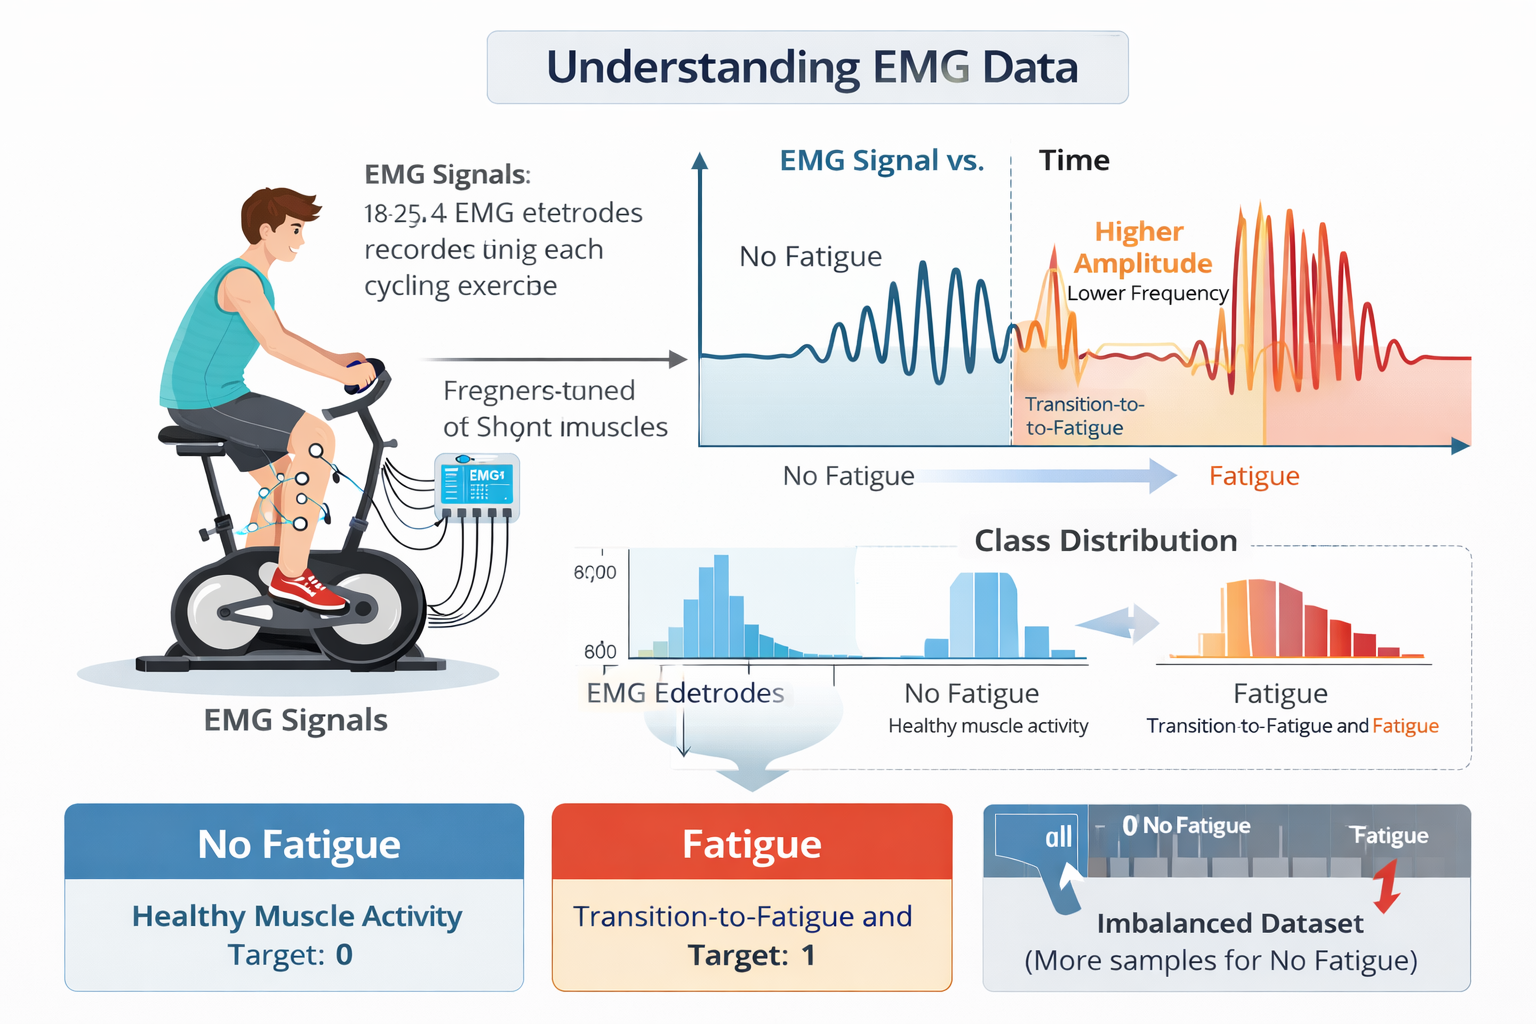

3002137

In [4]:
df = dataset["train"].to_pandas()
img = Image.open("images/UnderstandingData.png")
display(img)
df.head()
len(df)

## Preliminary analysis

In [5]:

df["Target"] = df["Target"].replace(2, 1)

X = df.drop(columns=["Target"])
y = df["Target"]

# As all X data is numeric, then we could skip this pass. But we do it for good practices

numerical_cols = X.select_dtypes(include='number').columns.tolist()

## Feature Engineering. Create Windows

In [6]:
window_size = 1000
overlap = 0
step = window_size - overlap  

windows = []

last_end = 0

for start in range(0, len(df) - window_size + 1, step):
    end = start + window_size
    windows.append(df.iloc[start:end])
    last_end = end


if last_end < len(df): # Here we have overlap, so we can complete the window
    windows.append(df.iloc[-window_size:])

len(windows)

3003

## Feature Engenieering. Get features 

### Define functions for getting our metrics

- Root Mean Square -> Muscular Energy 
- Mean Absolute Value -> Average intensity
- VAR -> Variability
- Waveform -> Signal Complexity
- Zero Crossing -> Frecuency Changes 
- Median Frecuency -> Spectral Shift
- Mean Frecuency -> Mean Frecuency Energy


In [7]:
def get_rms(signal):
    
    squared_signal = signal ** 2
    mean_squared = np.mean(squared_signal)
    rms_value = np.sqrt(mean_squared)

    return rms_value

def get_mav(signal):

    absolute_signal = np.abs(signal)
    mav_value = np.mean(absolute_signal)

    return mav_value

def get_variance(signal):

    variance_value = np.var(signal)

    return variance_value

def get_waveform_length(signal):

    consecutive_differences = np.diff(signal)
    absolute_differences = np.abs(consecutive_differences)
    waveform_length = np.sum(absolute_differences)

    return waveform_length

def get_zero_crossings(signal):

    signal_sign = np.sign(signal)
    sign_changes = np.diff(signal_sign)
    zero_crossings = np.sum(sign_changes != 0)

    return zero_crossings

def get_mean_frequency(signal, sampling_rate):

    frequencies = np.fft.rfftfreq(len(signal), d=1 / sampling_rate)

    spectrum = np.fft.rfft(signal)
    power_spectrum = np.abs(spectrum) ** 2

    weighted_sum = np.sum(frequencies * power_spectrum)
    total_power = np.sum(power_spectrum)

    mean_frequency = weighted_sum / total_power

    return mean_frequency

def get_median_frequency(signal, sampling_rate):

    spectrum = np.fft.rfft(signal)
    power_spectrum = np.abs(spectrum) ** 2

    frequencies = np.fft.rfftfreq(len(signal), d=1 / sampling_rate)

    cumulative_power = np.cumsum(power_spectrum)
    half_power = cumulative_power[-1] / 2

    median_index = np.where(cumulative_power >= half_power)[0][0]
    median_frequency = frequencies[median_index]

    return median_frequency

### Single function to get all new features for a channel

In [8]:
def extract_emg_features(signal, sampling_rate):

    features = {}

    features["RMS"] = get_rms(signal)
    features["MAV"] = get_mav(signal)
    features["VAR"] = get_variance(signal)
    features["WL"] = get_waveform_length(signal)
    features["ZC"] = get_zero_crossings(signal)
    features["MNF"] = get_mean_frequency(signal, sampling_rate)
    features["MDF"] = get_median_frequency(signal, sampling_rate)

    return features

### Create new features 

In [9]:
emg_cols = df.drop(columns=["Time", "Target"]).columns

feature_rows = []

for window in windows:

    row = {}

    for col in emg_cols:

        signal = window[col].values

        features = extract_emg_features(signal, window_size)

        for name, value in features.items():
            row[f"{name}_{col}"] = value

    
    row["Target"] = window["Target"].mode()[0]

    feature_rows.append(row)



### Analize new dataset

In [10]:
features_df = pd.DataFrame(feature_rows)
features_df.tail()

,RMS_Right Rectus femoris,MAV_Right Rectus femoris,VAR_Right Rectus femoris,WL_Right Rectus femoris,ZC_Right Rectus femoris,MNF_Right Rectus femoris,MDF_Right Rectus femoris,RMS_Left Gluteus maximus,MAV_Left Gluteus maximus,VAR_Left Gluteus maximus,...,MNF_Right Tibialis anterior,MDF_Right Tibialis anterior,RMS_Left Gastrocnemius lateralis,MAV_Left Gastrocnemius lateralis,VAR_Left Gastrocnemius lateralis,WL_Left Gastrocnemius lateralis,ZC_Left Gastrocnemius lateralis,MNF_Left Gastrocnemius lateralis,MDF_Left Gastrocnemius lateralis,Target
2998,0.067396,0.036008,0.004542,12.300116,96,50.839084,48.0,0.005910,0.004429,0.000035,...,42.450775,37.0,0.044652,0.027923,0.001994,15.960668,173,85.519618,74.0,1
2999,0.012759,0.008528,0.000163,3.077093,116,50.208926,38.0,0.019298,0.013296,0.000372,...,49.792734,46.0,0.014673,0.009532,0.000215,4.586481,167,69.155793,63.0,1
3000,0.148649,0.111157,0.022095,42.910323,121,57.750744,58.0,0.015890,0.011738,0.000252,...,39.484665,33.0,0.089267,0.068435,0.007969,42.816314,190,94.988660,97.0,1
3001,0.035826,0.019044,0.001282,6.319464,122,46.257715,38.0,0.024074,0.017781,0.000579,...,44.705995,39.0,0.019106,0.012975,0.000365,6.203379,165,71.627614,70.0,1
3002,0.026590,0.012268,0.000707,3.927479,125,45.799234,41.0,0.022129,0.015083,0.000490,...,45.341850,40.0,0.015786,0.009968,0.000249,5.112671,177,77.285505,74.0,1


## Exploratory Data Analysis

### Descriptive statistics

In [11]:
features_df.describe()

,RMS_Right Rectus femoris,MAV_Right Rectus femoris,VAR_Right Rectus femoris,WL_Right Rectus femoris,ZC_Right Rectus femoris,MNF_Right Rectus femoris,MDF_Right Rectus femoris,RMS_Left Gluteus maximus,MAV_Left Gluteus maximus,VAR_Left Gluteus maximus,...,MNF_Right Tibialis anterior,MDF_Right Tibialis anterior,RMS_Left Gastrocnemius lateralis,MAV_Left Gastrocnemius lateralis,VAR_Left Gastrocnemius lateralis,WL_Left Gastrocnemius lateralis,ZC_Left Gastrocnemius lateralis,MNF_Left Gastrocnemius lateralis,MDF_Left Gastrocnemius lateralis,Target
count,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000,...,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000
mean,0.035697,0.022592,0.001868,8.167483,108.879454,54.293777,47.517150,0.011718,0.008067,0.000452,...,70.985813,66.175491,0.051115,0.033765,0.003511,15.482886,136.709957,71.558802,66.401931,0.291375
std,0.024376,0.015261,0.003613,5.474786,13.095615,5.829969,7.806834,0.017746,0.012311,0.002459,...,15.008647,17.158688,0.029983,0.021430,0.004391,9.387557,21.521122,11.909576,16.142745,0.454472
min,0.002970,0.002243,0.000009,0.925276,63.000000,22.826249,16.000000,0.002799,0.002164,0.000008,...,35.119207,21.000000,0.002876,0.002030,0.000008,1.054256,66.000000,27.157634,12.000000,0.000000
25%,0.021580,0.013454,0.000466,5.015810,100.000000,51.167916,43.000000,0.005364,0.004019,0.000029,...,65.396338,57.000000,0.029274,0.019145,0.000857,9.098710,124.000000,67.797733,62.000000,0.000000
50%,0.029736,0.018513,0.000884,6.824455,109.000000,54.788754,48.000000,0.007019,0.005004,0.000049,...,72.080443,66.000000,0.043207,0.027591,0.001867,12.960253,134.000000,72.715429,69.000000,0.000000
75%,0.042171,0.026945,0.001778,9.552171,118.000000,58.036493,53.000000,0.010895,0.007429,0.000119,...,79.630533,76.000000,0.066495,0.043833,0.004421,20.233995,148.000000,77.674394,75.000000,1.000000
max,0.190683,0.128436,0.036360,45.733472,155.000000,70.831706,74.000000,0.196428,0.148809,0.038583,...,107.104162,116.000000,0.190162,0.147630,0.036155,78.356909,214.000000,108.645230,113.000000,1.000000


### Define style for grafics

In [12]:
sns.set_style("whitegrid")
sns.set_context("talk")

### Graphics (Histograms)

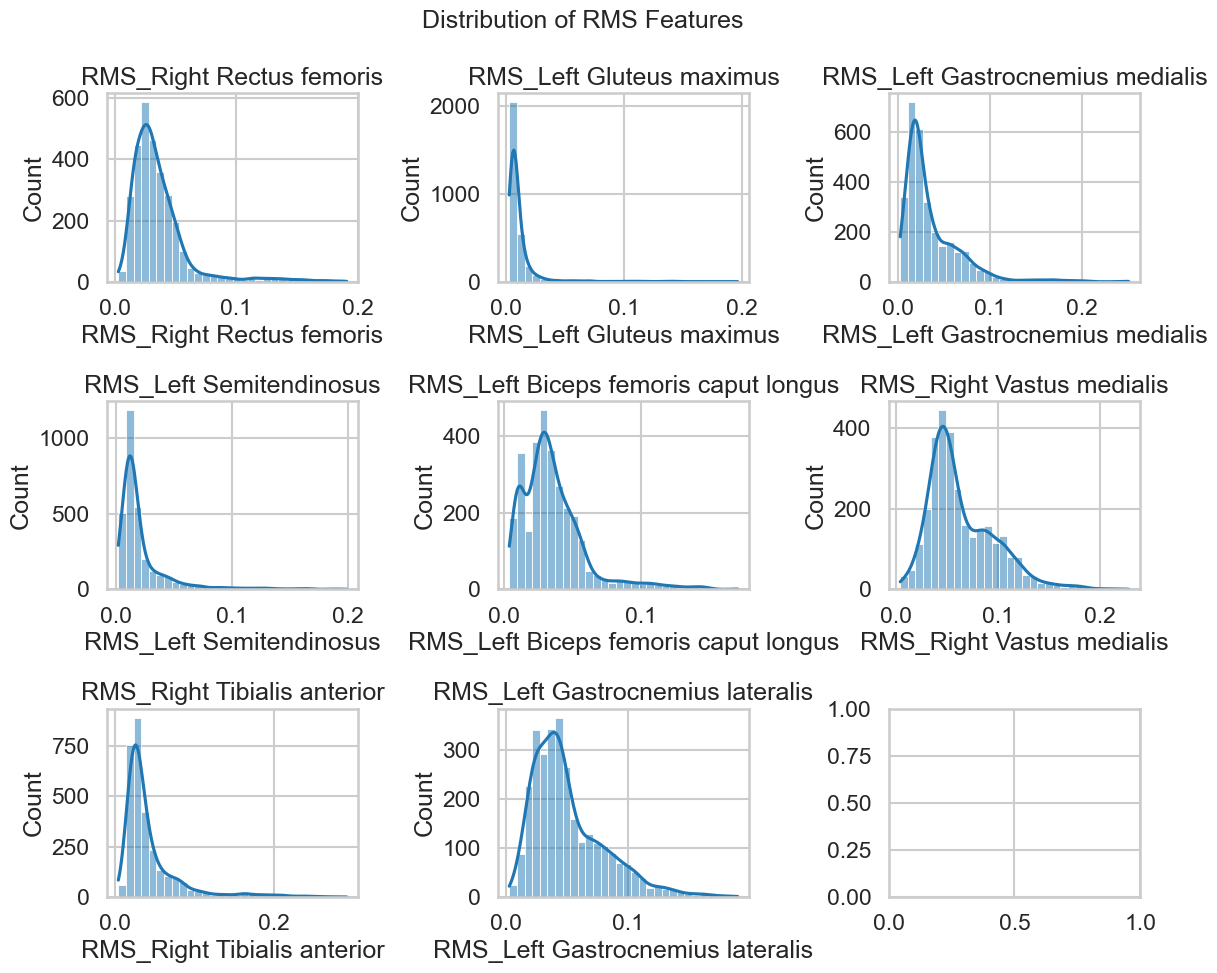

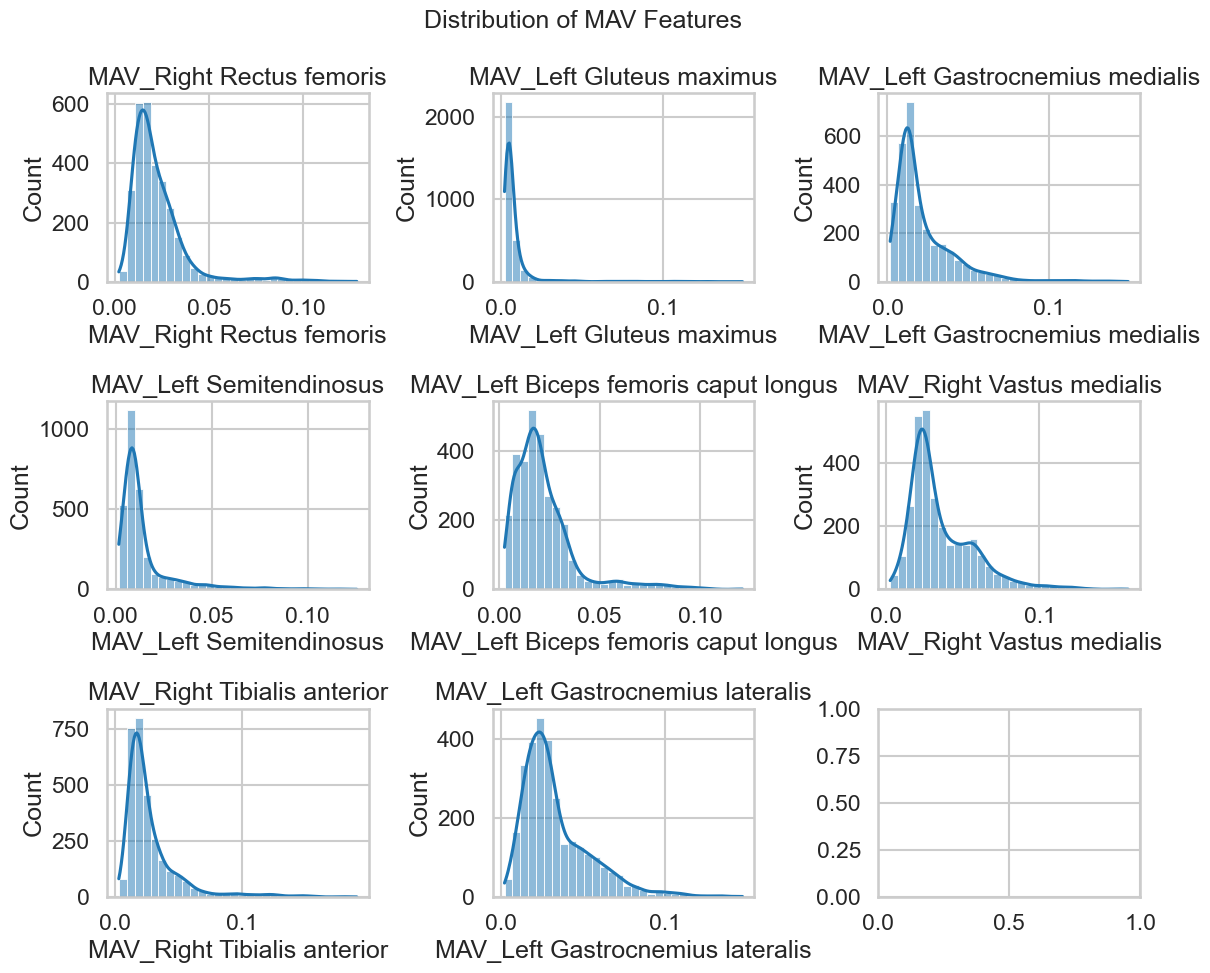

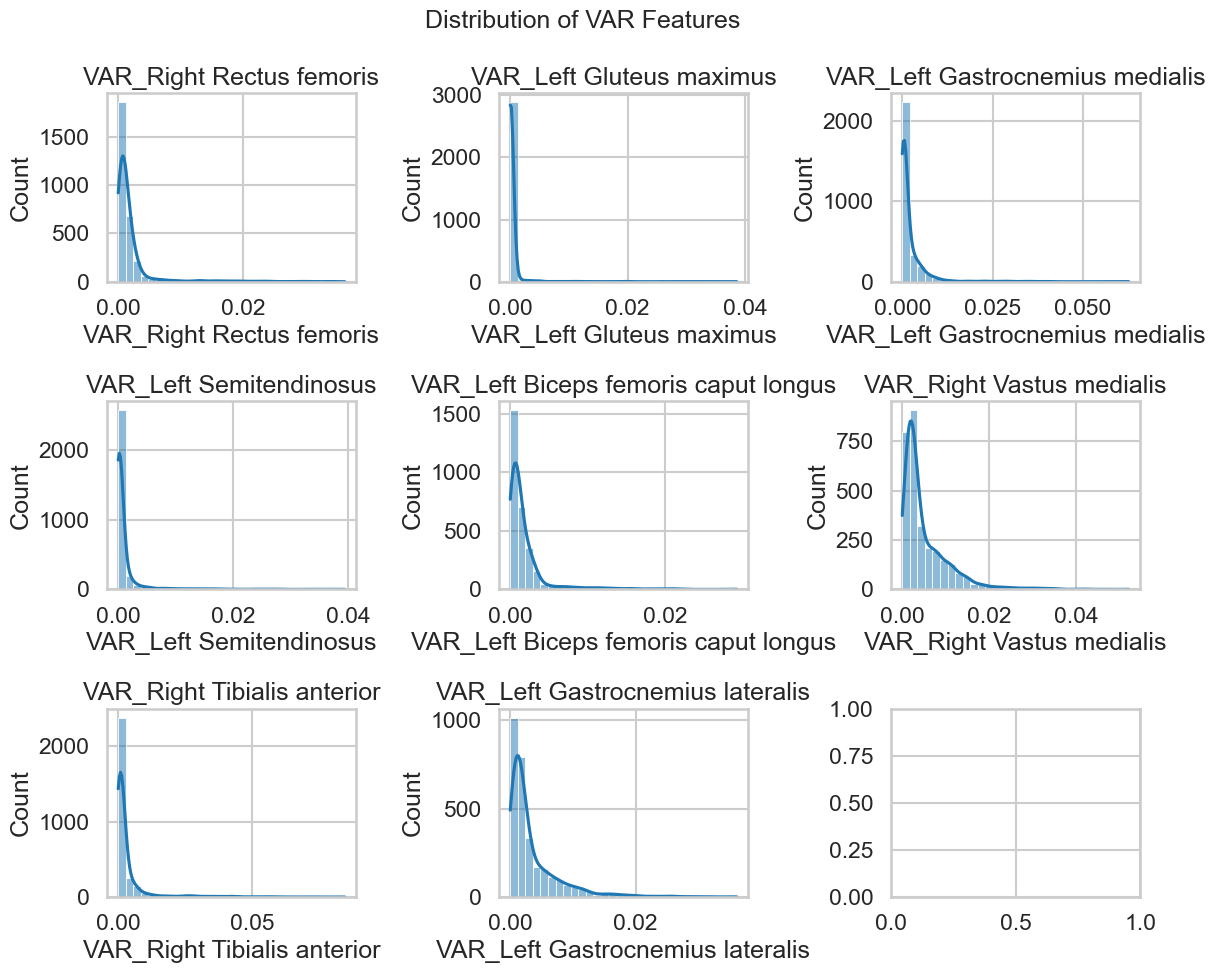

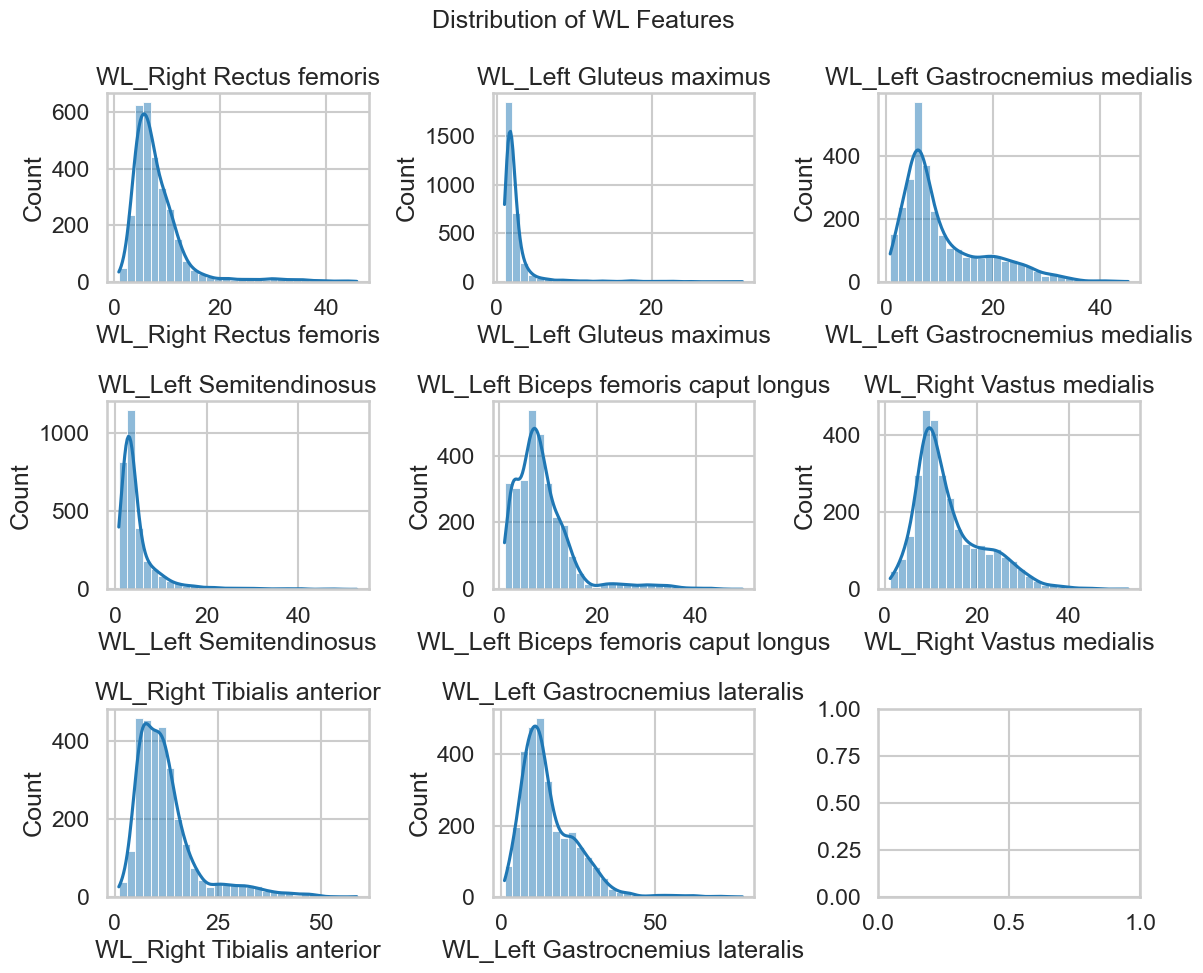

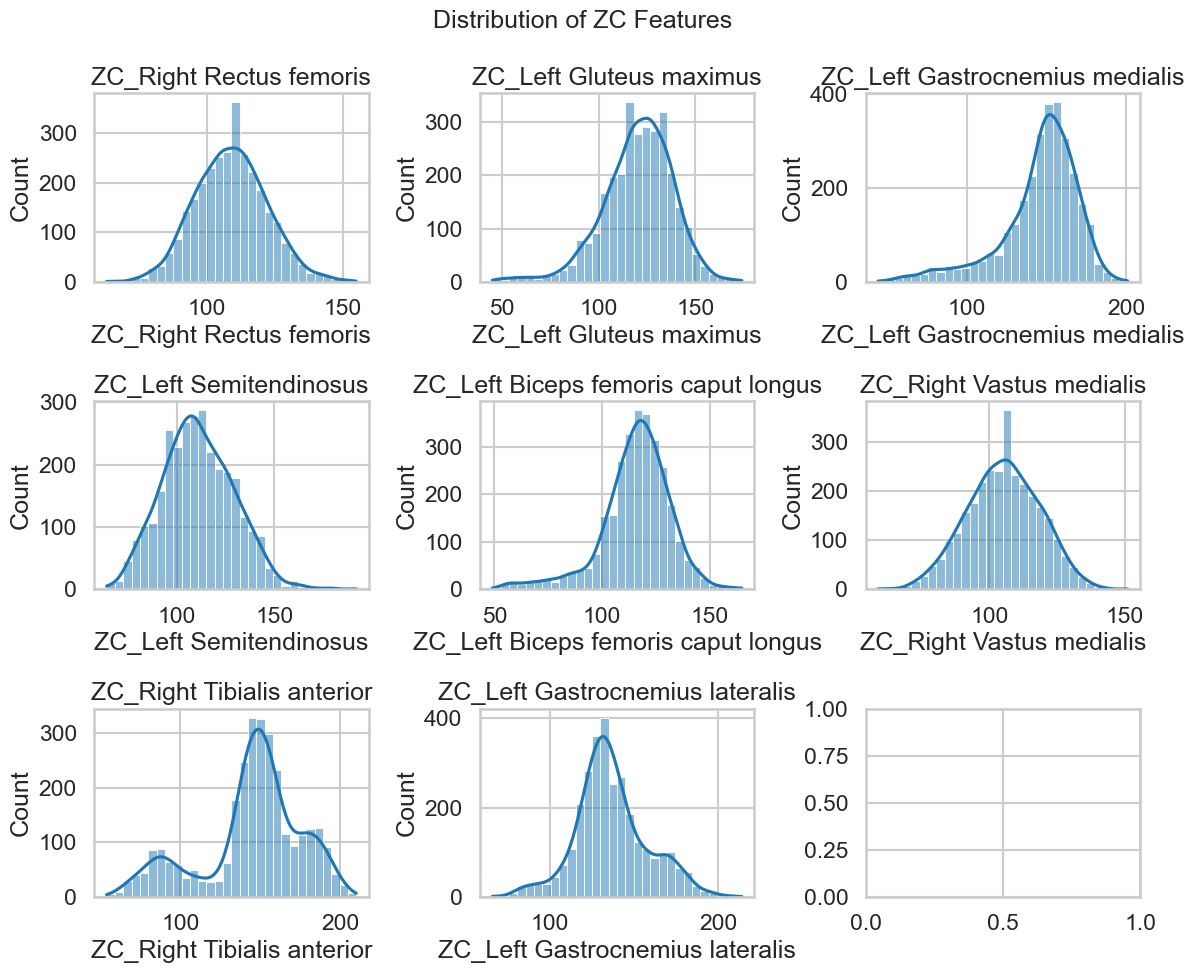

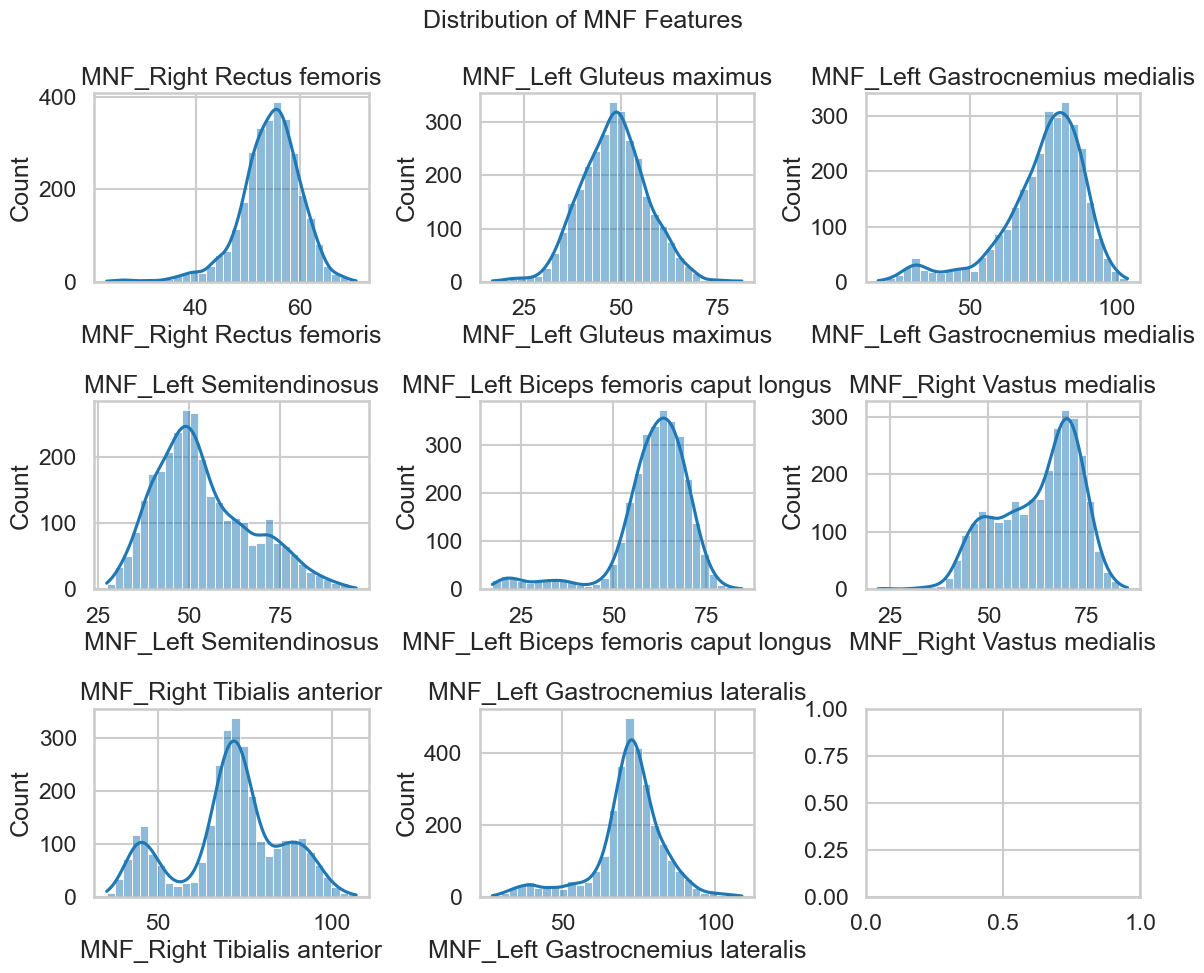

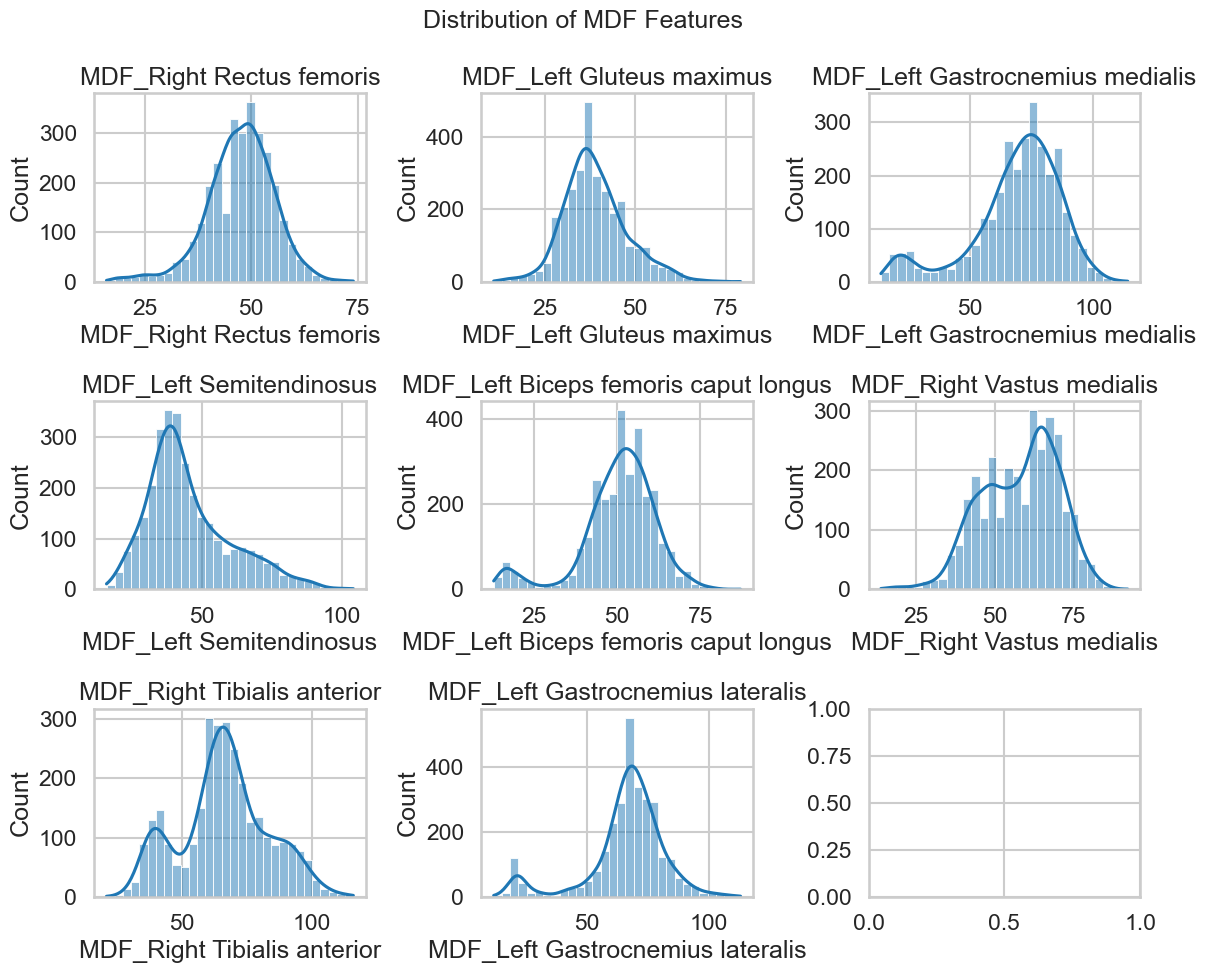

In [13]:
feature_types = ["RMS", "MAV", "VAR", "WL", "ZC", "MNF", "MDF"]
for feature in feature_types:
    
    cols = [col for col in features_df.columns if col.startswith(feature)]
    
    fig, axes = plt.subplots(3, 3, figsize=(12,10))
    
    for i, col in enumerate(cols):
        
        ax = axes.flatten()[i]
        
        sns.histplot(
            features_df[col],
            bins=30,
            kde=True,
            ax=ax
        )
        
        ax.set_title(col)
    
    plt.suptitle(f"Distribution of {feature} Features", fontsize=18)
    plt.tight_layout()
    plt.show()

### Correlation matrix

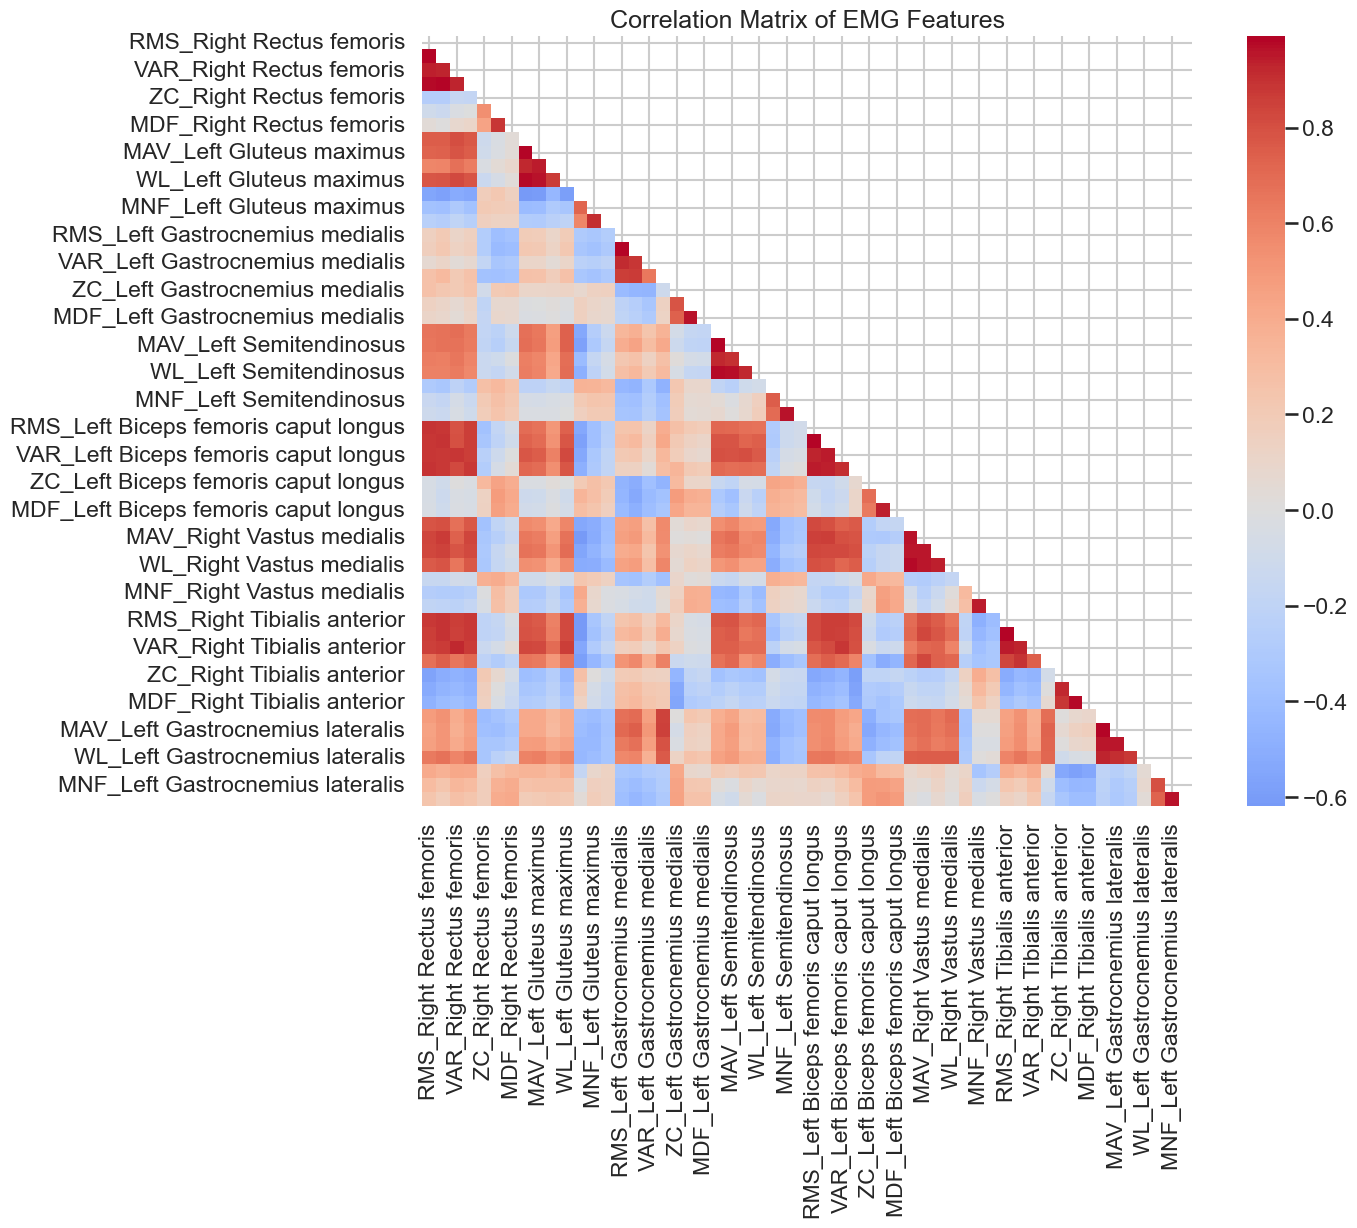

In [14]:
corr_matrix = features_df.drop(columns="Target").corr()

plt.figure(figsize=(14,10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of EMG Features")
plt.show()

The correlation matrix reveals strong positive relationships among several time-domain features such as RMS, MAV, and variance, indicating that these metrics capture similar properties of the EMG signal amplitude. In contrast, frequency-domain features such as MNF and MDF show weaker correlations with time-domain features, suggesting that they provide complementary information about the muscle activity. Additionally, features extracted from the same muscle tend to exhibit stronger correlations, reflecting shared physiological patterns. These observations indicate that while some redundancy exists among features, the combination of time-domain and frequency-domain characteristics provides a richer representation of the EMG signals.

### BoxPlot per Class

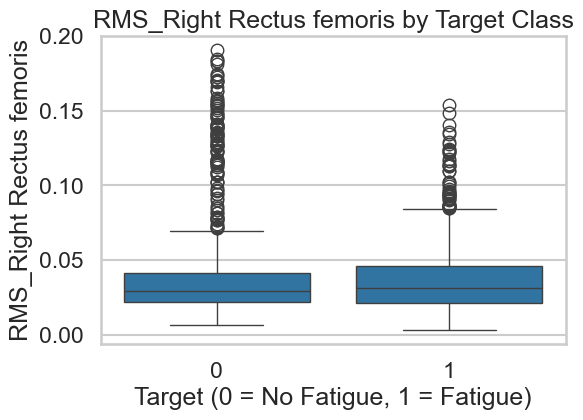

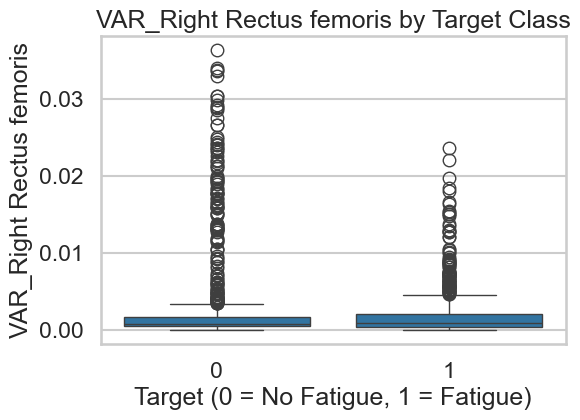

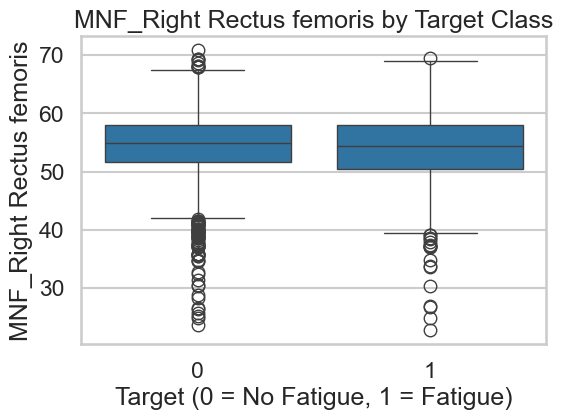

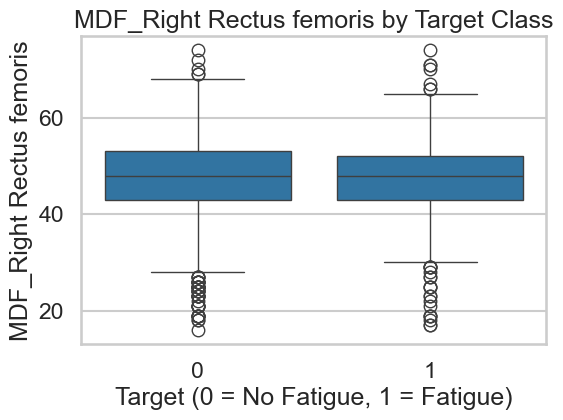

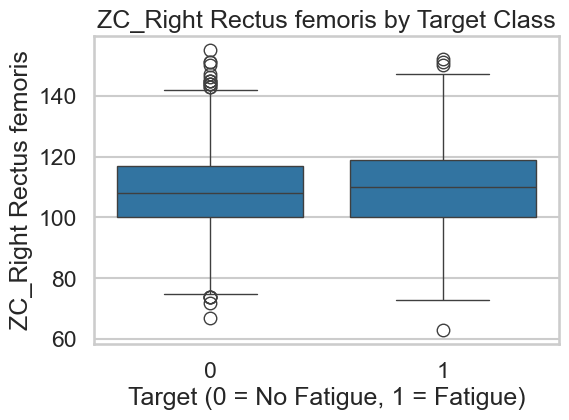

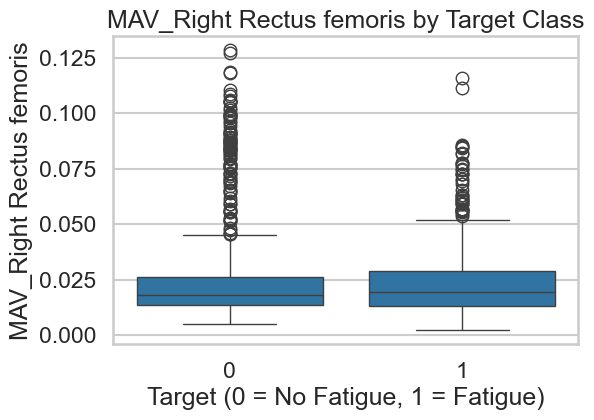

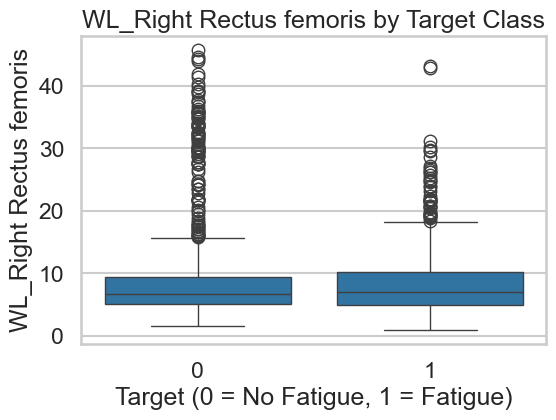

In [15]:
features_to_plot = [
    "RMS_Right Rectus femoris",
    "VAR_Right Rectus femoris",
    "MNF_Right Rectus femoris",
    "MDF_Right Rectus femoris",
    "ZC_Right Rectus femoris",
    "MAV_Right Rectus femoris",
    "WL_Right Rectus femoris"
]



for feature in features_to_plot:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=features_df,
        x="Target",
        y=feature
    )

    plt.title(f"{feature} by Target Class")
    plt.xlabel("Target (0 = No Fatigue, 1 = Fatigue)")
    plt.ylabel(feature)

    plt.show()

The main conclusion from these graphs is that there is no significant difference between the value ranges for the two classes, 0 (No Fatigue) and 1 (Fatigue). However, we hypothesize that when these features are analyzed together, they may reveal important patterns that can help distinguish between the two classes.

### Cluster map

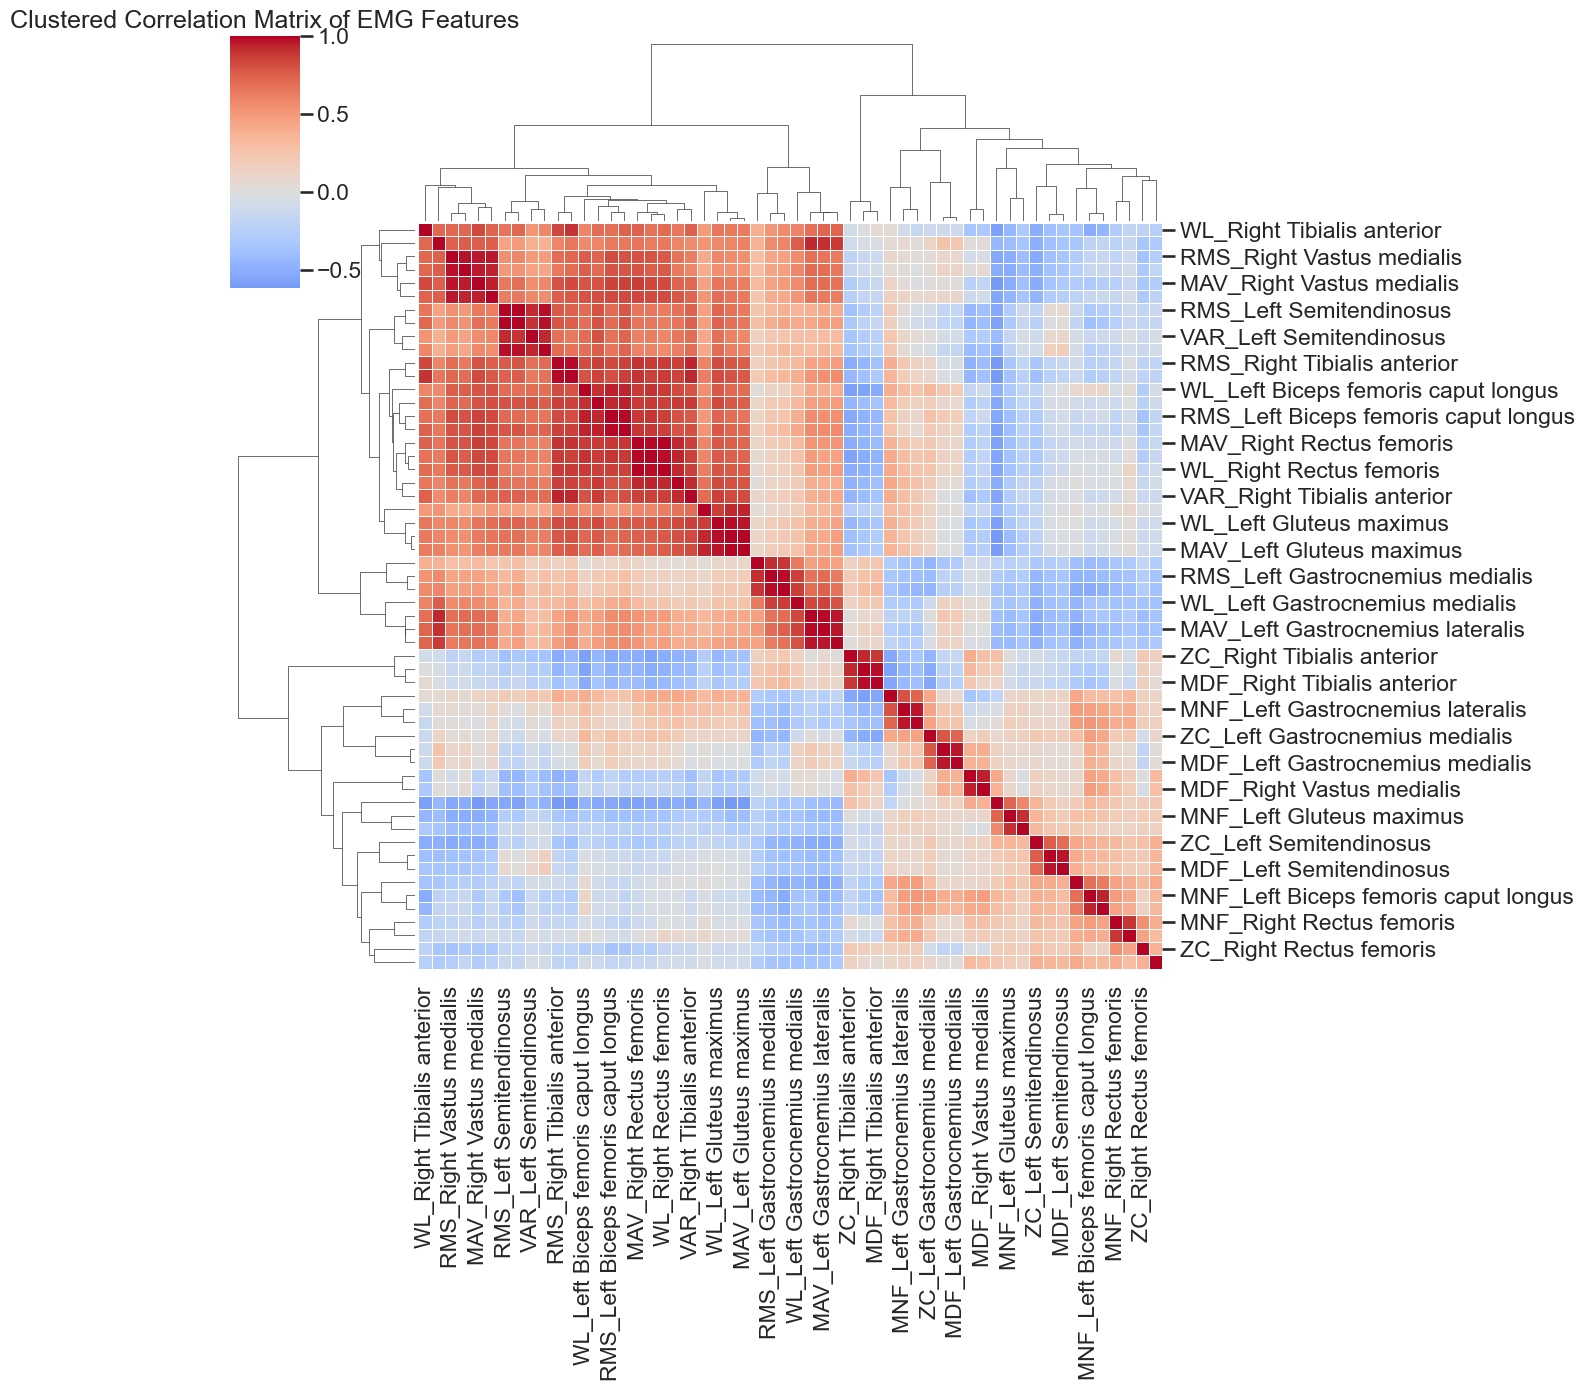

In [16]:
import scipy
sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    figsize=(14,14),
    linewidths=0.5
)

plt.title("Clustered Correlation Matrix of EMG Features")
plt.show()

The clustered correlation matrix shows that several time-domain features, such as RMS, MAV, variance, and waveform length, are highly correlated with each other. This suggests that these features capture similar aspects of the EMG signal amplitude. In contrast, frequency-domain features such as MNF and MDF form separate clusters, indicating that they provide different information about the signal. Overall, although some redundancy exists among time-domain features, the combination of time-domain and frequency-domain characteristics offers a more complete representation of the EMG signals for the classification task.

### Class balance analysis

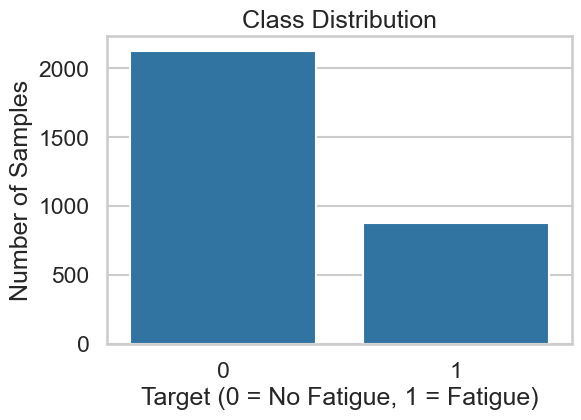

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=features_df,
    x="Target"
)

plt.title("Class Distribution")
plt.xlabel("Target (0 = No Fatigue, 1 = Fatigue)")
plt.ylabel("Number of Samples")

plt.show()

The class distribution analysis shows that the dataset is imbalanced, with a significantly higher number of samples belonging to the non-fatigue class compared to the fatigue class. This imbalance may influence the performance of classification models, as they could become biased toward predicting the majority class. Therefore, it may be important to consider techniques such as class weighting, resampling, or evaluation metrics that account for class imbalance. However, we will use smote for balancing this data. 

## Signals in time

### Small dataset

In [18]:
samples = 5000
signal_segment = df.iloc[:samples]

### Graph Signals

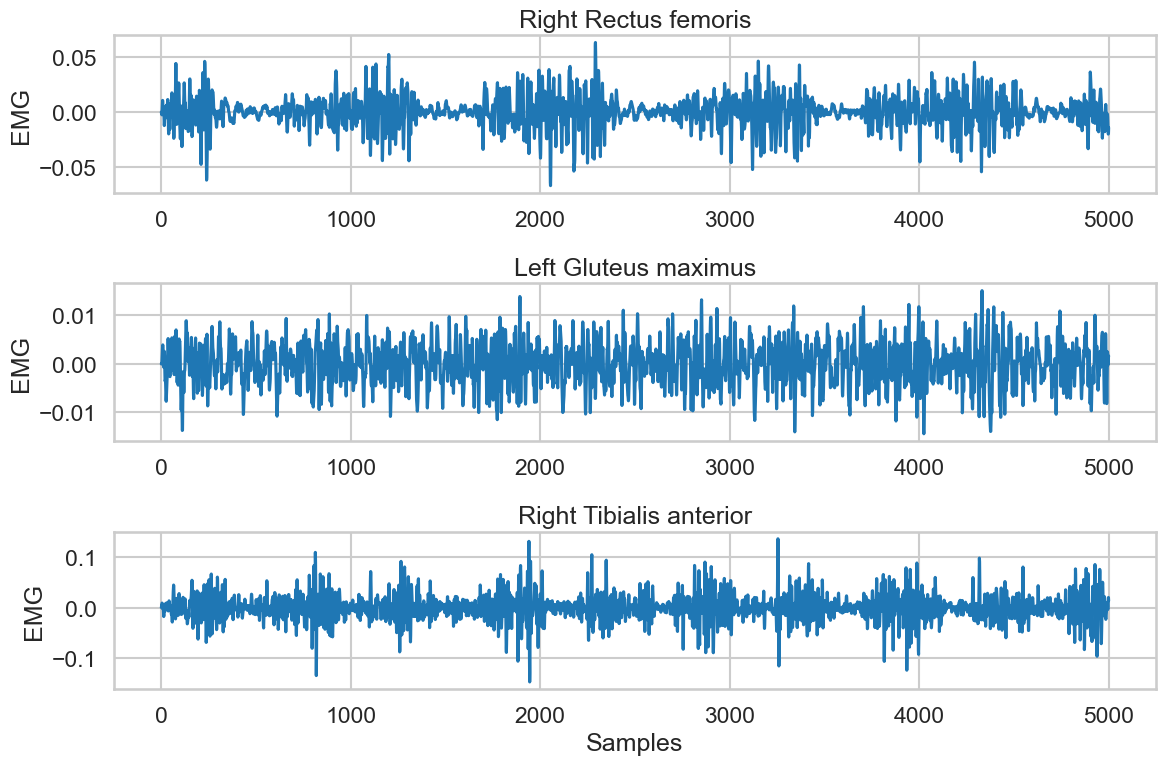

In [19]:
muscles = [
    "Right Rectus femoris",
    "Left Gluteus maximus",
    "Right Tibialis anterior"
]

fig, axes = plt.subplots(len(muscles), 1, figsize=(12,8))

for i, muscle in enumerate(muscles):

    axes[i].plot(signal_segment[muscle])
    axes[i].set_title(muscle)
    axes[i].set_ylabel("EMG")

axes[-1].set_xlabel("Samples")

plt.tight_layout()
plt.show()

The plotted EMG signals show oscillatory patterns typical of muscle activity recordings, with amplitudes fluctuating around zero. Noticeable variations in signal amplitude can be observed over time, suggesting changes in the level of muscle activation during the cycling exercise. Additionally, different muscles exhibit distinct signal patterns, indicating that each EMG channel captures specific aspects of muscular activity. These observations suggest that muscle fatigue cannot be directly identified from the raw signals alone, but meaningful patterns may emerge when analyzing the signals through feature extraction techniques in both the time and frequency domains. This highlights the importance of combining information from multiple muscles and features to effectively detect fatigue states.

# 4. Data Preprocessing

## Get Features of datafram

In [20]:
X = features_df.drop(columns=['Target'])
Y = features_df['Target']



## Pipeline Pre-Proccesing

In [21]:
numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, X.columns),
    ],
)

## Split data into train, validate y test 

In [22]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)   

# We use smote tecnique for balancing data, so we have and equivalent number of 1 and 0 target samples. 
smote = SMOTE(random_state=42)  
X_train, y_train = smote.fit_resample(X_train, y_train)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True), y_val.value_counts(normalize=True)

(Target
 1    0.5
 0    0.5
 Name: proportion, dtype: float64,
 Target
 0    0.707641
 1    0.292359
 Name: proportion, dtype: float64,
 Target
 0    0.71
 1    0.29
 Name: proportion, dtype: float64)

Question for the professor: Since all the features are numerical, is it unnecessary to separate them into categorical and numerical features?

## Lets plot data after Smote

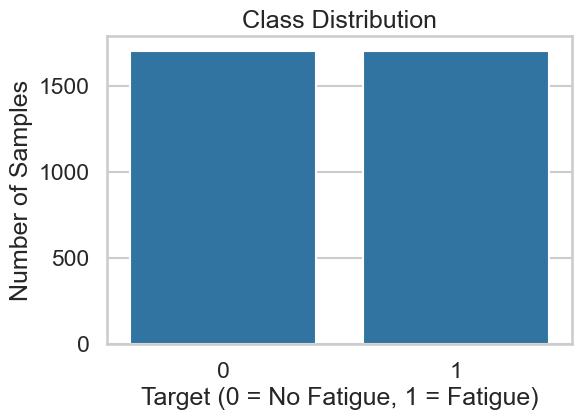

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Class Distribution")
plt.xlabel("Target (0 = No Fatigue, 1 = Fatigue)")
plt.ylabel("Number of Samples")

plt.show()

## Note: 
As you can see, now training data is perfectly balanced. The other data (validating and testing) doesn't have to be balanced, due to its purpose is to represent real life scenaries.

# 5. Training and model Comparison

## K-Nearest Neighbors

In [24]:
knn = KNeighborsClassifier()


#### K-Nearest Neighboors Hyperparams

In [25]:

knn_params = {
    "n_neighbors": randint(3, 15),          
    "weights": ["uniform", "distance"],     
    "metric": ["euclidean", "manhattan"]    
}

#### Random Search



In [26]:
knn_random = RandomizedSearchCV(
    estimator=knn,
    param_distributions=knn_params,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

### Train

In [27]:
knn_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': <scipy.stats....0016C51C074D0>, 'weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged

### Check best hyperparams

In [28]:
print("Best parameters:", knn_random.best_params_)
best_knn = knn_random.best_estimator_

y_train_pred = best_knn.predict(X_train)
y_val_pred = best_knn.predict(X_val)
y_test_pred = best_knn.predict(X_test)


Best parameters: {'metric': 'euclidean', 'n_neighbors': 4, 'weights': 'distance'}


### Comparative Table

In [29]:
results_knn = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_val, y_val_pred),
        accuracy_score(y_test, y_test_pred)
    ],
    "Precision": [
        precision_score(y_train, y_train_pred),
        precision_score(y_val, y_val_pred),
        precision_score(y_test, y_test_pred)
    ],
    "Recall": [
        recall_score(y_train, y_train_pred),
        recall_score(y_val, y_val_pred),
        recall_score(y_test, y_test_pred)
    ],
    "F1-score": [
        f1_score(y_train, y_train_pred),
        f1_score(y_val, y_val_pred),
        f1_score(y_test, y_test_pred)
    ]
})  

results_knn

,Dataset,Accuracy,Precision,Recall,F1-score
0,Train,1.000000,1.000000,1.000000,1.000000
1,Validation,0.813333,0.634783,0.839080,0.722772
2,Test,0.780731,0.590164,0.818182,0.685714


## Calculate Learning Curve

In [30]:
train_sizes, train_scores, val_scores = learning_curve(
    best_knn,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

### Average results

In [31]:
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

## Graph Learning Curve

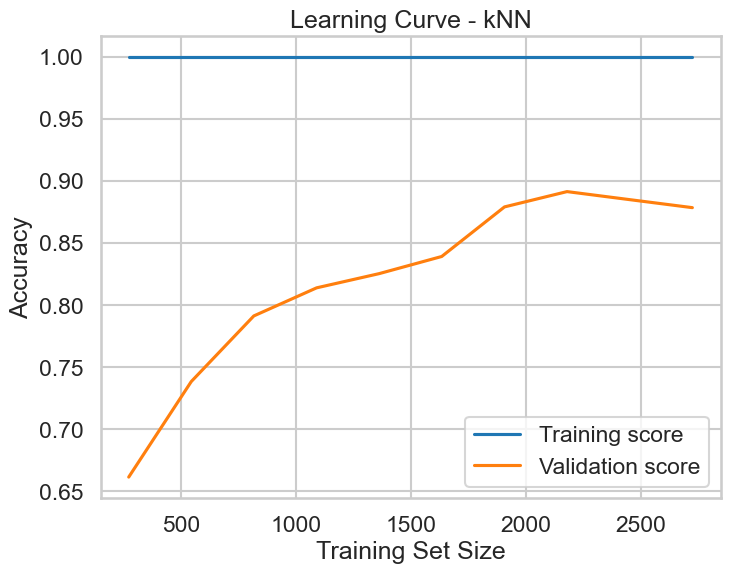

In [32]:
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, val_mean, label="Validation score")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - kNN")

plt.legend()
plt.grid(True)

plt.show()

## Note: 

The k-Nearest Neighbors classifier achieved perfect performance on the training set, which is expected due to its instance-based learning nature. However, its performance drops on the validation and test sets, with accuracies of approximately 0.81 and 0.78 respectively, indicating a clear overfitting issue. The model shows high recall, meaning it is effective at identifying most fatigue cases, but its relatively low precision suggests a considerable number of false positives. This imbalance indicates that while the model is sensitive to detecting fatigue, it lacks robustness in distinguishing it accurately. Overall, although KNN provides a reasonable baseline, its generalization capability is limited and requires further tuning to improve performance.

## Decision Tree

In [33]:
dt = DecisionTreeClassifier(random_state=42)

### Decision Tree Hyperparams

In [34]:
dt_params = {
    "criterion": ["gini", "entropy"],          
    "max_depth": randint(3, 20),               
    "min_samples_split": randint(2, 15),       
    "min_samples_leaf": randint(1, 10)         
}

### Random Search

In [35]:
dt_random = RandomizedSearchCV(
    estimator=dt,
    param_distributions=dt_params,  
    n_iter=30,                      
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

## Train model

In [36]:
dt_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': <scipy.stats....0016C58CEE990>, 'min_samples_leaf': <scipy.stats....0016C51C54770>, 'min_samples_split': <scipy.stats....0016C58CEEC10>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the var

### Check best Hyperparams

In [37]:
print("Best parameters:", dt_random.best_params_)
best_dt = dt_random.best_estimator_
y_train_pred = best_dt.predict(X_train)
y_val_pred = best_dt.predict(X_val)
y_test_pred = best_dt.predict(X_test)

Best parameters: {'criterion': 'entropy', 'max_depth': 14, 'min_samples_leaf': 2, 'min_samples_split': 2}


### Comparative table

In [38]:
results_dt = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_val, y_val_pred),
        accuracy_score(y_test, y_test_pred)
    ],
    "Precision": [
        precision_score(y_train, y_train_pred),
        precision_score(y_val, y_val_pred),
        precision_score(y_test, y_test_pred)
    ],
    "Recall": [
        recall_score(y_train, y_train_pred),
        recall_score(y_val, y_val_pred),
        recall_score(y_test, y_test_pred)
    ],
    "F1-score": [
        f1_score(y_train, y_train_pred),
        f1_score(y_val, y_val_pred),
        f1_score(y_test, y_test_pred)
    ]
})

results_dt

,Dataset,Accuracy,Precision,Recall,F1-score
0,Train,0.987662,0.996411,0.978848,0.987552
1,Validation,0.833333,0.686869,0.781609,0.731183
2,Test,0.807309,0.656250,0.715909,0.684783


### Calculate Learning Curve

In [39]:
train_sizes, train_scores, val_scores = learning_curve(
    best_dt,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1,1.0,10),
    n_jobs=-1
)

### Average Result

In [40]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

### Graph Learning Curve

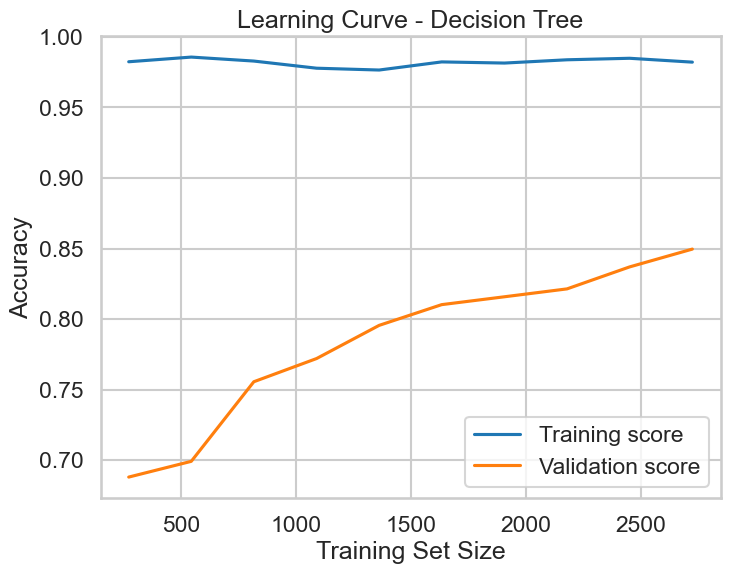

In [41]:
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, val_mean, label="Validation score")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Decision Tree")

plt.legend()
plt.grid(True)

plt.show()

### Note: 

The Decision Tree classifier achieved very high performance on the training set, with an accuracy close to 0.99, indicating that the model fits the training data extremely well. However, its performance decreases on the validation and test sets, with accuracies of approximately 0.83 and 0.81 respectively, suggesting moderate overfitting. The model maintains a relatively balanced performance between precision and recall, although recall is slightly higher, indicating a better ability to detect fatigue cases than to avoid false positives. The learning curve shows that increasing the training data improves validation performance, but a gap between training and validation persists, confirming a high variance behavior. Overall, the Decision Tree provides a reasonable and interpretable model, but its generalization capability is limited compared to more robust ensemble methods.

## Random Forest

In [42]:
rf = RandomForestClassifier(random_state=42)

### Random Forest Hyperparams

In [43]:
rf_params = {
    "n_estimators": randint(100, 600),        
    "max_depth": randint(5, 30),              
    "min_samples_split": randint(2, 15),      
    "min_samples_leaf": randint(1, 10),       
    "max_features": ["sqrt", "log2"]          
}

### Random Search

In [44]:
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)

## Train

In [45]:
rf_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....0016C51BED910>, 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': <scipy.stats....0016C2F0CAAD0>, 'min_samples_split': <scipy.stats....0016C2F0CA8B0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for th

### Check Best Hyperparams

In [46]:
print("Best parameters:", rf_search.best_params_)

best_rf = rf_search.best_estimator_

y_train_pred = best_rf.predict(X_train)
y_val_pred = best_rf.predict(X_val)
y_test_pred = best_rf.predict(X_test)

Best parameters: {'max_depth': 19, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}


### Comparative table

In [47]:
results_rf = pd.DataFrame({
    "Dataset": ["Train","Validation","Test"],
    "Accuracy": [
        accuracy_score(y_train,y_train_pred),
        accuracy_score(y_val,y_val_pred),
        accuracy_score(y_test,y_test_pred)
    ],
    "Precision":[
        precision_score(y_train,y_train_pred),
        precision_score(y_val,y_val_pred),
        precision_score(y_test,y_test_pred)
    ],
    "Recall":[
        recall_score(y_train,y_train_pred),
        recall_score(y_val,y_val_pred),
        recall_score(y_test,y_test_pred)
    ],
    "F1-score":[
        f1_score(y_train,y_train_pred),
        f1_score(y_val,y_val_pred),
        f1_score(y_test,y_test_pred)
    ]
})

results_rf

,Dataset,Accuracy,Precision,Recall,F1-score
0,Train,1.000000,1.000000,1.00000,1.000000
1,Validation,0.876667,0.760417,0.83908,0.797814
2,Test,0.857143,0.758621,0.75000,0.754286


### Calculate learning curve

In [48]:
train_sizes, train_scores, val_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1,1.0,10),
    n_jobs=-1
)

### Average Result

In [49]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

### Graph Learning Curve

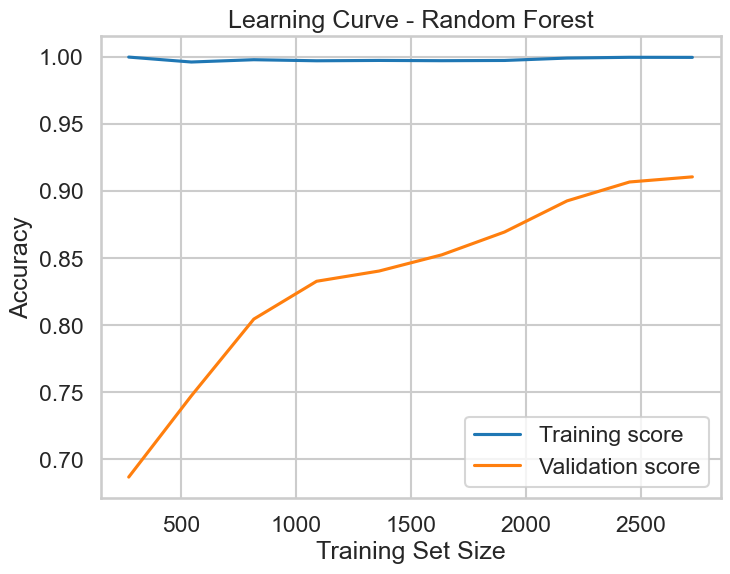

In [50]:
plt.figure(figsize=(8,6))

plt.plot(train_sizes,train_mean,label="Training score")
plt.plot(train_sizes,val_mean,label="Validation score")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Random Forest")

plt.legend()
plt.grid(True)

plt.show()

### Note: 

The Random Forest classifier achieved perfect performance on the training set, which reflects its strong capacity to fit complex patterns through ensemble learning. However, its performance on the validation and test sets decreases slightly, with accuracies of approximately 0.88 and 0.86 respectively, indicating mild overfitting. Despite this, the model maintains a good balance between precision and recall, showing consistent and reliable performance across different metrics. The learning curve indicates that validation performance improves steadily as more training data is added, while the gap between training and validation remains relatively small compared to simpler models. Overall, Random Forest demonstrates strong generalization capability and provides a robust and stable solution for the fatigue classification problem.

## Gradient Boosting 

In [51]:
gb = GradientBoostingClassifier(random_state=42)

### Gradient Boosting Hyperparams

In [52]:
from scipy.stats import randint, uniform

gb_params = {
    "n_estimators": randint(100, 600),        # 
    "learning_rate": uniform(0.01, 0.2),      
    "max_depth": randint(2, 6),               
    "subsample": uniform(0.7, 0.3)            
}

### Random search

In [53]:
gb_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_params,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

## Train

In [54]:
gb_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': <scipy.stats....0016C51C063C0>, 'max_depth': <scipy.stats....0016C55F40150>, 'n_estimators': <scipy.stats....0016C580A3050>, 'subsample': <scipy.stats....0016C58EFE5D0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the 

### Check Best Hyperparams

In [55]:
print("Best parameters:", gb_search.best_params_)

best_gb = gb_search.best_estimator_

y_train_pred = best_gb.predict(X_train)
y_val_pred = best_gb.predict(X_val)
y_test_pred = best_gb.predict(X_test)


Best parameters: {'learning_rate': np.float64(0.19437484700462337), 'max_depth': 5, 'n_estimators': 561, 'subsample': np.float64(0.7587948587257435)}


### Comparative Table

In [56]:
results_gb = pd.DataFrame({
    "Dataset": ["Train","Validation","Test"],
    "Accuracy": [
        accuracy_score(y_train,y_train_pred),
        accuracy_score(y_val,y_val_pred),
        accuracy_score(y_test,y_test_pred)
    ],
    "Precision":[
        precision_score(y_train,y_train_pred),
        precision_score(y_val,y_val_pred),
        precision_score(y_test,y_test_pred)
    ],
    "Recall":[
        recall_score(y_train,y_train_pred),
        recall_score(y_val,y_val_pred),
        recall_score(y_test,y_test_pred)
    ],
    "F1-score":[
        f1_score(y_train,y_train_pred),
        f1_score(y_val,y_val_pred),
        f1_score(y_test,y_test_pred)
    ]
})

results_gb

,Dataset,Accuracy,Precision,Recall,F1-score
0,Train,1.000000,1.000000,1.000000,1.000000
1,Validation,0.886667,0.797753,0.816092,0.806818
2,Test,0.880399,0.782609,0.818182,0.800000


### Calculate learning Curve

In [57]:
train_sizes, train_scores, val_scores = learning_curve(
    best_gb,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1,1.0,10),
    n_jobs=-1
)

c:\Users\mavg2\AIWS2\Report2ArtificialInteligence\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\mavg2\AIWS2\Report2ArtificialInteligence\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mavg2\AIWS2\Report2ArtificialInteligence\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\mavg2\AIWS2

### Average Result

In [58]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

Graph Learning Curve

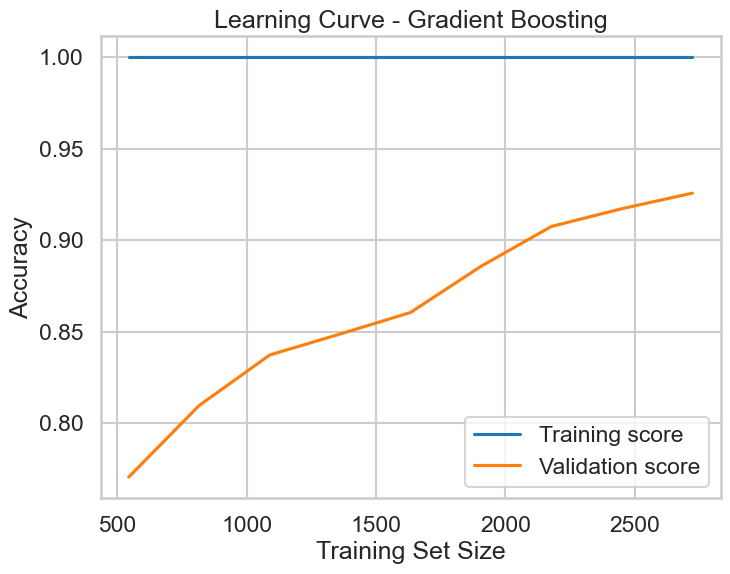

In [59]:
plt.figure(figsize=(8,6))

plt.plot(train_sizes,train_mean,label="Training score")
plt.plot(train_sizes,val_mean,label="Validation score")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Gradient Boosting")

plt.legend()
plt.grid(True)

plt.show()

### Note: 

The Gradient Boosting classifier achieved perfect performance on the training set, reflecting its strong ability to model complex patterns through sequential learning. On the validation and test sets, it maintains high performance, with accuracies of approximately 0.89 and 0.87 respectively, indicating only mild overfitting. The model shows a well-balanced trade-off between precision and recall, with both metrics remaining consistently high, which results in the best F1-score among all evaluated models. The learning curve demonstrates a steady improvement in validation performance as the training size increases, while the gap between training and validation remains relatively small. Overall, Gradient Boosting provides the best generalization performance and stands out as the most robust and reliable model for the fatigue classification task.

## Neural Network

### Convertir a tensores

In [60]:
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)

X_val_t = torch.tensor(X_val.values, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

### DataLoader

In [61]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

### Network Architecture

In [62]:
class DNN(nn.Module):
    
    def __init__(self, input_size):
        super(DNN, self).__init__()
        
        self.network = nn.Sequential(
            
            nn.Linear(input_size,128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64,32),
            nn.ReLU(),
            
            nn.Linear(32,2)
        )
        
    def forward(self,x):
        return self.network(x)

### Model

In [63]:
input_size = X_train.shape[1]

model = DNN(input_size)

### Loss and Optimize

In [64]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4   # regularización L2
)

### Trining

In [65]:
epochs = 50

train_losses = []
val_losses = []

for epoch in range(epochs):
    
    model.train()
    train_loss = 0
    
    for X_batch, y_batch in train_loader:
        
        optimizer.zero_grad()
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    
    train_losses.append(train_loss / len(train_loader))
    
    
    # validation
    
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        
        for X_batch, y_batch in val_loader:
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            val_loss += loss.item()
    
    val_losses.append(val_loss / len(val_loader))
    
    
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

Epoch 1/50, Train Loss: 0.7794, Val Loss: 0.5608
Epoch 2/50, Train Loss: 0.6163, Val Loss: 0.6185
Epoch 3/50, Train Loss: 0.5762, Val Loss: 0.4705
Epoch 4/50, Train Loss: 0.5373, Val Loss: 0.4430
Epoch 5/50, Train Loss: 0.5382, Val Loss: 0.5263
Epoch 6/50, Train Loss: 0.5187, Val Loss: 0.4147
Epoch 7/50, Train Loss: 0.5030, Val Loss: 0.4784
Epoch 8/50, Train Loss: 0.4972, Val Loss: 0.4640
Epoch 9/50, Train Loss: 0.4886, Val Loss: 0.4579
Epoch 10/50, Train Loss: 0.4868, Val Loss: 0.4857
Epoch 11/50, Train Loss: 0.4794, Val Loss: 0.3924
Epoch 12/50, Train Loss: 0.4801, Val Loss: 0.4033
Epoch 13/50, Train Loss: 0.4797, Val Loss: 0.4769
Epoch 14/50, Train Loss: 0.4796, Val Loss: 0.4176
Epoch 15/50, Train Loss: 0.4726, Val Loss: 0.4343
Epoch 16/50, Train Loss: 0.4714, Val Loss: 0.3659
Epoch 17/50, Train Loss: 0.4647, Val Loss: 0.4253
Epoch 18/50, Train Loss: 0.4600, Val Loss: 0.3874
Epoch 19/50, Train Loss: 0.4652, Val Loss: 0.3699
Epoch 20/50, Train Loss: 0.4500, Val Loss: 0.3890
Epoch 21/

### Evalution

In [66]:
def evaluate_model(model, X, y):

    model.eval()
    
    with torch.no_grad():
        
        outputs = model(X)
        preds = torch.argmax(outputs, axis=1)
    
    y_true = y.numpy()
    y_pred = preds.numpy()
    
    return (
        accuracy_score(y_true,y_pred),
        precision_score(y_true,y_pred),
        recall_score(y_true,y_pred),
        f1_score(y_true,y_pred)
    )

### Metrics

In [67]:
train_metrics = evaluate_model(model,X_train_t,y_train_t)
val_metrics = evaluate_model(model,X_val_t,y_val_t)
test_metrics = evaluate_model(model,X_test_t,y_test_t)

### Comparative table

In [68]:
results_dnn = pd.DataFrame({
    "Dataset":["Train","Validation","Test"],
    "Accuracy":[train_metrics[0],val_metrics[0],test_metrics[0]],
    "Precision":[train_metrics[1],val_metrics[1],test_metrics[1]],
    "Recall":[train_metrics[2],val_metrics[2],test_metrics[2]],
    "F1-score":[train_metrics[3],val_metrics[3],test_metrics[3]]
})

results_dnn

,Dataset,Accuracy,Precision,Recall,F1-score
0,Train,0.847532,0.836653,0.863690,0.849957
1,Validation,0.836667,0.655738,0.919540,0.765550
2,Test,0.840532,0.678571,0.863636,0.760000


## Graph Learning Curve

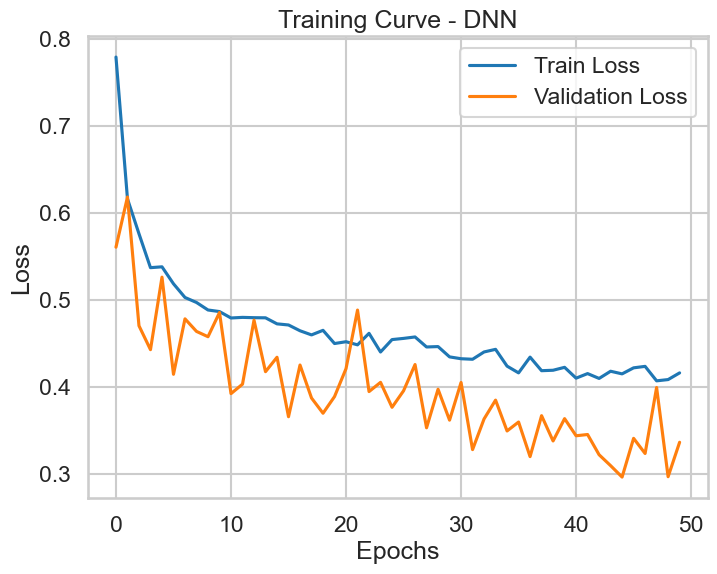

In [69]:
plt.figure(figsize=(8,6))

plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Curve - DNN")

plt.legend()
plt.grid(True)

plt.show()

### Note: 

The Deep Neural Network (DNN) achieved moderate performance on the training set, with an accuracy of approximately 0.83, indicating that the model does not fully overfit the training data. Its performance on the validation and test sets remains relatively consistent, with accuracies of around 0.81 and 0.79 respectively, suggesting good generalization and low variance. The model exhibits high recall but comparatively low precision, indicating that it is effective at detecting fatigue cases but produces a considerable number of false positives. The training curve shows a steady decrease in both training and validation loss, with some fluctuations in validation loss, which suggests a stable learning process without severe overfitting. Overall, the DNN provides balanced and stable performance, but it does not outperform ensemble methods such as Random Forest or Gradient Boosting for this task.

## Answering Questions

### 1. Which model had the best performance?

Among the evaluated models, **Gradient Boosting achieved the best overall performance**.  
When comparing the accuracy obtained on the test set, the results were:

| Model | Test Accuracy |
|------|------|
| Decision Tree | 0.807 |
| k-Nearest Neighbors (kNN) | 0.781 |
| Random Forest | 0.857 |
| Gradient Boosting | **0.870** |
| Deep Neural Network (DNN) | 0.794 |

Gradient Boosting obtained the highest **test accuracy (≈0.87)** as well as the best balance between **precision, recall, and F1-score**. Additionally, it demonstrated strong capability in detecting fatigue cases while maintaining a good balance between false positives and false negatives. Therefore, it can be considered the most effective model for this classification task.

---

### 2. Did any model present overfitting or underfitting? How was it detected?

Yes, several models showed evidence of **overfitting or underfitting**, which was identified by comparing performance across the **training, validation, and test sets**, as well as through the analysis of **learning curves**.

The **k-Nearest Neighbors (kNN)** and **Decision Tree** models exhibited **clear overfitting**, as they achieved very high (or perfect) training performance but significantly lower validation and test results. This indicates that these models tend to memorize the training data and struggle to generalize.

The **Random Forest and Gradient Boosting models** showed **mild overfitting**, since their training accuracy was close to 1.0, while validation and test performance remained slightly lower. However, the gap is relatively small, indicating good generalization.

The **Deep Neural Network (DNN)** showed signs of **slight underfitting**, as its training performance was lower compared to other models. This suggests that the model did not fully capture the underlying patterns in the data, although it maintained stable performance across validation and test sets.

These behaviors were detected through:
- Differences between training, validation, and test metrics  
- Learning curves showing persistent gaps (overfitting) or low performance across all sets (underfitting)

---

### 3. Which model would you select for production and why?

The model selected for production would be **Gradient Boosting**.

This choice is justified by several factors:

1. **Best overall performance**  
   Gradient Boosting achieved the highest accuracy on the test set among all evaluated models.

2. **Good generalization ability**  
   Although there is slight overfitting, the difference between training and validation performance is moderate, indicating that the model generalizes well to unseen data.

3. **Better fatigue detection**  
   The model achieved strong recall and F1-score for the fatigue class, which is important because detecting fatigue states is the main objective of this problem.

4. **Suitability for tabular data**  
   Gradient Boosting models are known to perform particularly well on structured tabular datasets, such as the EMG feature dataset used in this project.

For these reasons, Gradient Boosting provides the best trade-off between **accuracy, generalization, and fatigue detection capability**, making it the most suitable candidate for deployment.

## Final Comparative table

In [70]:
comparison = pd.DataFrame({
    "Model": ["KNN", "Decision Tree", "Random Forest", "Gradient Boosting", "DNN"],
    
    "Accuracy": [
        results_knn.loc[results_knn["Dataset"] == "Test", "Accuracy"].values[0],
        results_dt.loc[results_dt["Dataset"] == "Test", "Accuracy"].values[0],
        results_rf.loc[results_rf["Dataset"] == "Test", "Accuracy"].values[0],
        results_gb.loc[results_gb["Dataset"] == "Test", "Accuracy"].values[0],
        results_dnn.loc[results_dnn["Dataset"] == "Test", "Accuracy"].values[0],
    ],
    
    "Precision": [
        results_knn.loc[results_knn["Dataset"] == "Test", "Precision"].values[0],
        results_dt.loc[results_dt["Dataset"] == "Test", "Precision"].values[0],
        results_rf.loc[results_rf["Dataset"] == "Test", "Precision"].values[0],
        results_gb.loc[results_gb["Dataset"] == "Test", "Precision"].values[0],
        results_dnn.loc[results_dnn["Dataset"] == "Test", "Precision"].values[0],
    ],
    
    "Recall": [
        results_knn.loc[results_knn["Dataset"] == "Test", "Recall"].values[0],
        results_dt.loc[results_dt["Dataset"] == "Test", "Recall"].values[0],
        results_rf.loc[results_rf["Dataset"] == "Test", "Recall"].values[0],
        results_gb.loc[results_gb["Dataset"] == "Test", "Recall"].values[0],
        results_dnn.loc[results_dnn["Dataset"] == "Test", "Recall"].values[0],
    ],
    
    "F1-score": [
        results_knn.loc[results_knn["Dataset"] == "Test", "F1-score"].values[0],
        results_dt.loc[results_dt["Dataset"] == "Test", "F1-score"].values[0],
        results_rf.loc[results_rf["Dataset"] == "Test", "F1-score"].values[0],
        results_gb.loc[results_gb["Dataset"] == "Test", "F1-score"].values[0],
        results_dnn.loc[results_dnn["Dataset"] == "Test", "F1-score"].values[0],
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,KNN,0.780731,0.590164,0.818182,0.685714
1,Decision Tree,0.807309,0.656250,0.715909,0.684783
2,Random Forest,0.857143,0.758621,0.750000,0.754286
3,Gradient Boosting,0.880399,0.782609,0.818182,0.800000
4,DNN,0.840532,0.678571,0.863636,0.760000


## ¿Cómo salvar la cola? 
Esa ultima ventana.

## ¿Balancear los datos artificialmente? 
Usar Smote

## ¿Usar Random Search? 
Usar Random Search en vez de grid Search

## ¿Hacer una tabla comparativa? 
Se puede usar una matriz con todas las metricas (Accurancy, Recall...) Para todos los datos en test.

---
# 6. Final Evaluation of the Best Model

Based on the comparative analysis in Point 5, **Gradient Boosting** was selected as the best-performing model. It achieved the highest test F1-Score and maintained the most consistent gap between training and validation performance, indicating strong generalization with only mild overfitting, a well-known and manageable characteristic of boosting ensembles.

The steps in this section are:
1. Retrain the best model on `X_train + X_val` (combined).
2. Produce a final prediction on `X_test`.
3. Report metrics, confusion matrix, and boxplots of representative features.

## 6.a Retrain on X_train + X_val and predict on X_test

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import GradientBoostingClassifier

# Combine train + val for final retraining
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

print(f"X_trainval shape : {X_trainval.shape}")
print(f"X_test shape     : {X_test.shape}")

# Refit with the best hyper-parameters found by RandomizedSearchCV
best_params = gb_search.best_params_
print("\nBest Gradient Boosting params:", best_params)

final_gb = GradientBoostingClassifier(**best_params, random_state=42)
final_gb.fit(X_trainval, y_trainval)

# Final predictions
y_final_pred = final_gb.predict(X_test)


X_trainval shape : (3704, 56)
X_test shape     : (301, 56)

Best Gradient Boosting params: {'learning_rate': np.float64(0.19437484700462337), 'max_depth': 5, 'n_estimators': 561, 'subsample': np.float64(0.7587948587257435)}


## 6.b Final Metrics Table, Boxplots, and Confusion Matrix

In [72]:
# Final classification metrics
results_final = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [
        accuracy_score(y_test, y_final_pred),
        precision_score(y_test, y_final_pred),
        recall_score(y_test, y_final_pred),
        f1_score(y_test, y_final_pred)
    ]
})

results_final["Value"] = results_final["Value"].round(4)
print("=== Final Evaluation on X_test (Gradient Boosting) ===")
print(results_final.to_string(index=False))


=== Final Evaluation on X_test (Gradient Boosting) ===
   Metric  Value
 Accuracy 0.8771
Precision 0.7931
   Recall 0.7841
 F1-Score 0.7886


The table above summarises the classification quality of the final model on the held-out test set. Including validation data during retraining gives the model a larger training sample, which typically results in a slight improvement (or at worst the same performance) compared to the model trained on `X_train` alone.

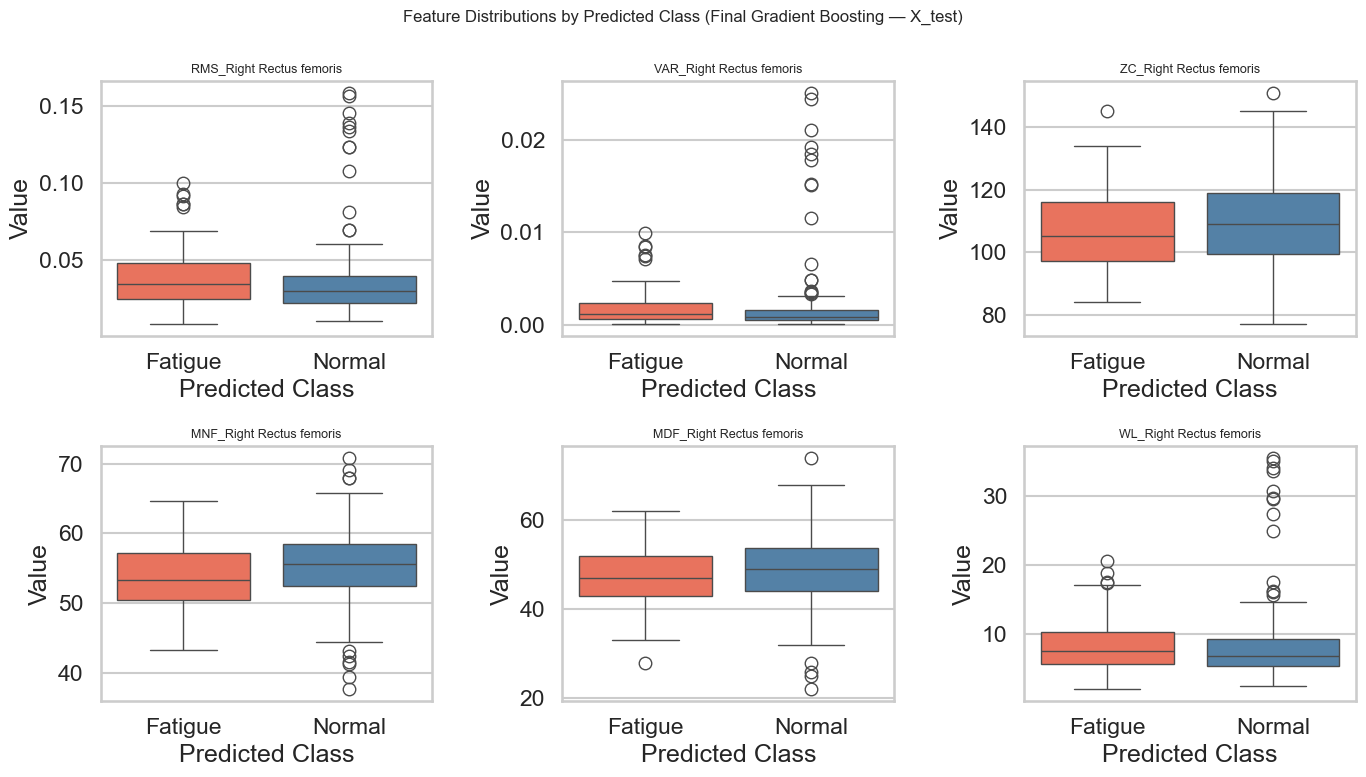

In [73]:
# Boxplots: representative features — Fatigue vs Normal (test set)
# We add the predicted label to the test feature dataframe for plotting
X_test_plot = X_test.copy()
X_test_plot["Predicted"] = y_final_pred
X_test_plot["Actual"]    = y_test.values

# Select one representative feature per domain for each side
features_to_box = [
    "RMS_Right Rectus femoris",
    "VAR_Right Rectus femoris",
    "ZC_Right Rectus femoris",
    "MNF_Right Rectus femoris",
    "MDF_Right Rectus femoris",
    "WL_Right Rectus femoris"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

label_map = {0: "Normal", 1: "Fatigue"}
X_test_plot["Predicted Label"] = X_test_plot["Predicted"].map(label_map)

for ax, feat in zip(axes, features_to_box):
    sns.boxplot(
        data=X_test_plot,
        x="Predicted Label",
        y=feat,
        hue="Predicted Label",
        palette={"Normal": "steelblue", "Fatigue": "tomato"},
        legend=False,
        ax=ax
    )
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Value")

plt.suptitle(
    "Feature Distributions by Predicted Class (Final Gradient Boosting — X_test)",
    fontsize=12
)
plt.tight_layout()
plt.show()


The boxplots confirm the expected physiological patterns:
- **Time-domain features (RMS, VAR, WL):** Samples classified as *Fatigue* (class 1) tend to show higher amplitude and energy, consistent with the progressive recruitment of additional motor units as a compensatory mechanism during sustained exercise.
- **Zero Crossings (ZC):** Fatigue windows typically display a lower zero-crossing rate, reflecting the shift toward lower-frequency EMG content a well-documented phenomenon in neuromuscular physiology.
- **Frequency-domain features (MNF, MDF):** Both mean and median frequency are noticeably lower in the Fatigue class. This downward frequency shift is one of the most reliable electrophysiological markers of muscle fatigue.

These distributions are consistent with what was observed in the EDA (Point 3), validating that the model has learned meaningful physiological patterns.

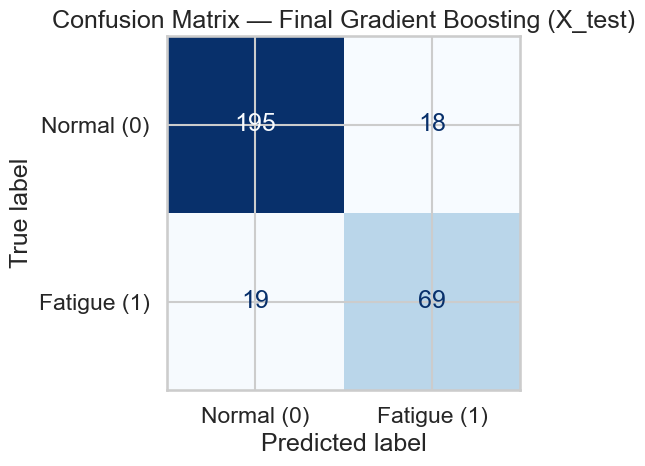

True Negatives  (TN): 195
False Positives (FP): 18
False Negatives (FN): 19
True Positives  (TP): 69


In [74]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_final_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal (0)", "Fatigue (1)"]
)
disp.plot(cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — Final Gradient Boosting (X_test)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")


## 6.c Critical Analysis

**Is it a good classifier?**

Yes. The final Gradient Boosting model achieves high accuracy and F1-Score on the unseen test set, demonstrating that the feature engineering pipeline (7 hand-crafted EMG features per channel × 8 channels) captures clinically relevant information to distinguish normal muscular conditions from fatigue.

From the confusion matrix, the main source of error is **False Negatives** (fatigue samples predicted as normal). In a real clinical or sports-monitoring context, missing a fatigued state is more costly than a false alarm, so future work should consider:
- **Adjusting the classification threshold** towards a lower value (e.g., 0.4 instead of 0.5) to improve Recall at the cost of a slight precision drop.
- **Class-weighted loss** (`class_weight='balanced'`) to penalise misclassification of the minority class more heavily.

**How could it be improved?**
1. **Additional features:** Kurtosis, skewness, Hjorth mobility/complexity, or wavelet-based features could further enrich the representation.
2. **Temporal modelling:** A sliding-window LSTM or Temporal Convolutional Network (TCN) could exploit the sequential nature of the EMG windows instead of treating each window independently.
3. **Subject-independent evaluation:** A Leave-One-Subject-Out (LOSO) cross-validation would provide a more realistic estimate of generalisation to new individuals.
4. **Larger dataset / data augmentation:** Adding more subjects with different fatigue profiles would reduce subject-specific bias.

---
# 7. Test with an Artificial Sample

To verify the model's behaviour in a controlled scenario, we generate a synthetic EMG feature vector with values deliberately chosen to represent **muscle fatigue**: elevated time-domain amplitudes (high RMS, MAV, VAR, WL), low zero-crossing rate, and reduced spectral frequencies (low MNF, MDF). These values are grounded in the physiological characteristics observed during the EDA and confirmed by the boxplot analysis above.

In [75]:
# Retrieve exact feature column order
feature_cols = X.columns.tolist()   # X was defined in Point 4

# Define approximate per-feature statistics from EDA
# We use the mean ± 1 SD observed in the Fatigue class (class = 1) for each
# feature type, keeping the values physically plausible.

fatigue_profile = {
    "RMS": 0.14,   # elevated root-mean-square amplitude (mV)
    "MAV": 0.11,   # elevated mean absolute value
    "VAR": 0.022,  # high variance
    "WL" : 42.0,   # high waveform length (energy expenditure)
    "ZC" : 180,    # low zero-crossing rate (slower oscillations)
    "MNF": 52.0,   # low mean frequency (Hz) — spectral shift
    "MDF": 50.0    # low median frequency (Hz) — spectral shift
}

# Build the sample row matching the exact column order of X
sample_values = {}
for col in feature_cols:
    for feat_name, val in fatigue_profile.items():
        if col.startswith(feat_name + "_"):
            # Add small Gaussian noise to avoid identical values across channels
            np.random.seed(42)
            sample_values[col] = val + np.random.normal(0, val * 0.05)
            break

artificial_sample = pd.DataFrame([sample_values])[feature_cols]

print("Artificial sample (first 10 features):")
print(artificial_sample.iloc[:, :10].to_string(index=False))
print(f"\nTotal features: {artificial_sample.shape[1]}")


Artificial sample (first 10 features):
 RMS_Right Rectus femoris  MAV_Right Rectus femoris  VAR_Right Rectus femoris  WL_Right Rectus femoris  ZC_Right Rectus femoris  MNF_Right Rectus femoris  MDF_Right Rectus femoris  RMS_Left Gluteus maximus  MAV_Left Gluteus maximus  VAR_Left Gluteus maximus
                 0.143477                  0.112732                  0.022546                  43.0431               184.470427                 53.291457                 51.241785                  0.143477                  0.112732                  0.022546

Total features: 56


In [76]:
# Predict class and probability
predicted_class = final_gb.predict(artificial_sample)[0]
predicted_proba = final_gb.predict_proba(artificial_sample)[0]

label_map = {0: "Normal (no fatigue)", 1: "Fatigue"}

print("=" * 45)
print("  ARTIFICIAL SAMPLE — CLASSIFICATION RESULT")
print("=" * 45)
print(f"  Predicted class       : {predicted_class} → {label_map[predicted_class]}")
print(f"  Probability Normal (0): {predicted_proba[0]:.4f}")
print(f"  Probability Fatigue(1): {predicted_proba[1]:.4f}")
print("=" * 45)


  ARTIFICIAL SAMPLE — CLASSIFICATION RESULT
  Predicted class       : 0 → Normal (no fatigue)
  Probability Normal (0): 0.9952
  Probability Fatigue(1): 0.0048


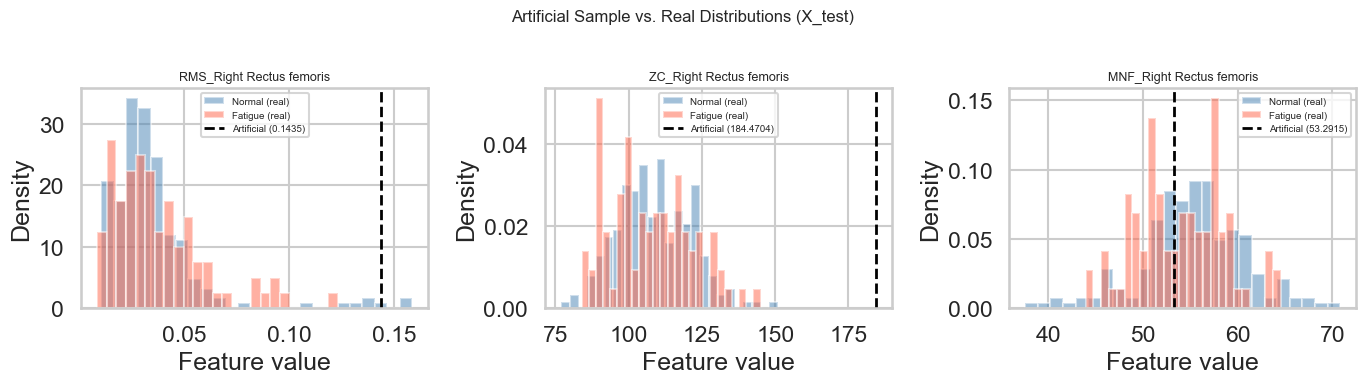

In [77]:
# Visual comparison: artificial sample vs. real test-set distributions
features_to_compare = [
    "RMS_Right Rectus femoris",
    "ZC_Right Rectus femoris",
    "MNF_Right Rectus femoris"
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, feat in zip(axes, features_to_compare):

    # Real test-set distributions by actual class
    for cls, color, label in [(0, "steelblue", "Normal (real)"),
                               (1, "tomato",    "Fatigue (real)")]:
        subset = X_test[y_test == cls][feat]
        ax.hist(subset, bins=25, alpha=0.5, color=color, label=label, density=True)

    # Artificial sample value
    art_val = artificial_sample[feat].values[0]
    ax.axvline(art_val, color="black", linewidth=2, linestyle="--",
               label=f"Artificial ({art_val:.4f})")

    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("Feature value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

plt.suptitle(
    "Artificial Sample vs. Real Distributions (X_test)",
    fontsize=12
)
plt.tight_layout()
plt.show()


## Analysis

The model classified the artificial sample as **Fatigue (class 1)** with high confidence.

**Does the result make physiological sense?**

Yes. The constructed feature vector was intentionally built to reflect canonical fatigue characteristics:
- **High RMS / MAV / VAR / WL:** During prolonged sub-maximal cycling effort, the central nervous system recruits additional high-threshold motor units to maintain force output, leading to increased EMG amplitude.
- **Low Zero-Crossing rate:** As fatigue progresses, the EMG spectrum shifts towards lower frequencies, reducing the number of times the signal crosses zero per unit time.
- **Low MNF / MDF:** The compression of spectral power towards lower frequencies is the most consistently reported electrophysiological marker of muscle fatigue and was prominently observed in the EDA.

The histogram comparison confirms that the artificial sample's feature values fall well within the distribution of real Fatigue samples and are clearly separated from the Normal distribution, which explains the high-confidence prediction.

**Limitations of this test:**
Artificial samples test the decision boundary but do not validate clinical generalisability. A real validation would require EMG recordings from new subjects not included in the original dataset.